
HARD SQUARE SIMULATION WITH PERIODIC BOUNDARIES

Saving Hard Square Simulation GIF
Particles: 36
Packing fraction: 0.640
Periodic display: True
Filename: hard_square_periodic.gif

Equilibrating (300 sweeps)...
  Sweep 100/300
  Sweep 200/300
  Sweep 300/300

Creating animation (150 frames)...
Saving to hard_square_periodic.gif...

Done! Saved as hard_square_periodic.gif

Running φ = 0.360...

Running φ = 0.444...

Running φ = 0.562...

Running φ = 0.735...

Running φ = 0.852...

Running φ = 1.000...


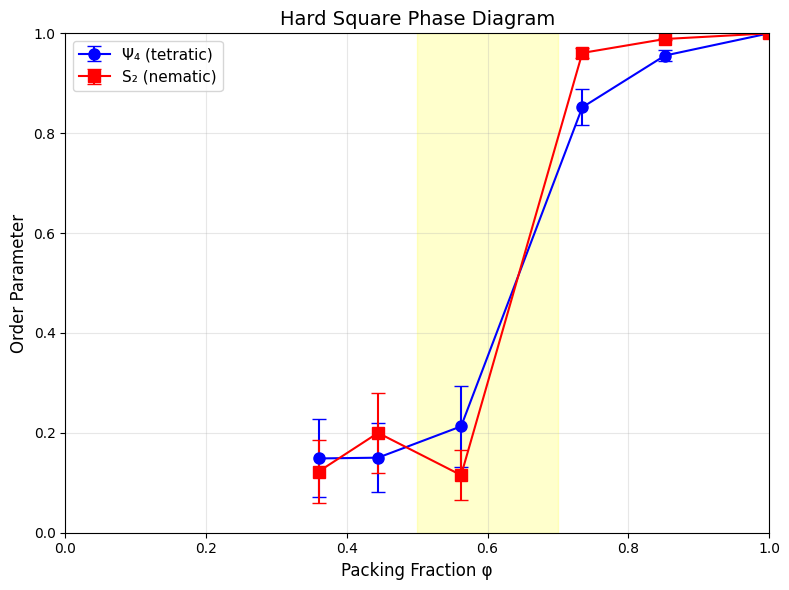

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Polygon
from scipy.spatial.distance import pdist
from scipy import stats
import random

class HardSquareSim:
    def __init__(self, N, side_length, box_size):
        self.N = N
        self.sigma = side_length
        self.L = box_size
        self.pos = self._init_grid()
        self.angles = np.zeros(N)
        
    def _init_grid(self):
        grid_size = int(np.ceil(np.sqrt(self.N)))
        spacing = self.L / grid_size
        pos = []
        for i in range(self.N):
            x = (i % grid_size) * spacing + spacing / 2
            y = (i // grid_size) * spacing + spacing / 2
            pos.append([x, y])
        return np.array(pos, dtype=float)

    def get_corners(self, center, angle):
        s, c = np.sin(angle), np.cos(angle)
        R = np.array([[c, -s], [s, c]])
        half = self.sigma / 2
        corners = np.array([[-half, -half], [half, -half], 
                           [half, half], [-half, half]])
        return center + corners @ R.T

    def get_corners_periodic(self, center, angle):
        """
        Get corners with periodic boundary handling.
        Returns list of corner arrays for all periodic images that are visible.
        """
        corners = self.get_corners(center, angle)
        all_images = []
        
        # Check if particle is near any boundary
        for dx in [-self.L, 0, self.L]:
            for dy in [-self.L, 0, self.L]:
                shifted_corners = corners + np.array([dx, dy])
                
                # Check if any part of this image is inside the box
                if (np.any(shifted_corners[:, 0] > 0) and 
                    np.any(shifted_corners[:, 0] < self.L) and
                    np.any(shifted_corners[:, 1] > 0) and 
                    np.any(shifted_corners[:, 1] < self.L)):
                    
                    # Clip corners to box boundaries for proper display
                    all_images.append(shifted_corners)
        
        return all_images

    def check_overlap(self, idx, new_pos, new_angle):
        corners1 = self.get_corners(new_pos, new_angle)
        for i in range(self.N):
            if i == idx:
                continue
            dp = self.pos[i] - new_pos
            dp -= self.L * np.round(dp / self.L)
            if np.linalg.norm(dp) > self.sigma * np.sqrt(2) * 1.1:
                continue
            corners2 = self.get_corners(new_pos + dp, self.angles[i])
            if self._sat_overlap(corners1, corners2):
                return True
        return False

    def _sat_overlap(self, c1, c2):
        for poly in [c1, c2]:
            for j in range(4):
                edge = poly[(j + 1) % 4] - poly[j]
                normal = np.array([-edge[1], edge[0]])
                p1 = c1 @ normal
                p2 = c2 @ normal
                if np.max(p1) < np.min(p2) or np.max(p2) < np.min(p1):
                    return False
        return True

    def step(self, dr_max=0.1, da_max=0.1):
        accepted = 0
        for _ in range(self.N):
            idx = random.randint(0, self.N - 1)
            old_p = self.pos[idx].copy()
            old_a = self.angles[idx]
            new_p = old_p + (np.random.rand(2) - 0.5) * dr_max
            new_a = old_a + (np.random.rand() - 0.5) * da_max
            new_p %= self.L
            if not self.check_overlap(idx, new_p, new_a):
                self.pos[idx] = new_p
                self.angles[idx] = new_a
                accepted += 1
        return accepted / self.N

    def packing_fraction(self):
        return self.N * self.sigma**2 / self.L**2

    # ============================================
    # STRUCTURAL ANALYSIS METHODS
    # ============================================
    
    def radial_distribution_function(self, n_bins=100, r_max=None):
        """Calculate g(r) - radial distribution function."""
        if r_max is None:
            r_max = self.L / 2
        
        dr = r_max / n_bins
        bins = np.linspace(0, r_max, n_bins + 1)
        hist = np.zeros(n_bins)
        
        for i in range(self.N):
            for j in range(i + 1, self.N):
                dp = self.pos[j] - self.pos[i]
                dp -= self.L * np.round(dp / self.L)
                r = np.linalg.norm(dp)
                
                if r < r_max:
                    bin_idx = int(r / dr)
                    if bin_idx < n_bins:
                        hist[bin_idx] += 2
        
        r_centers = (bins[:-1] + bins[1:]) / 2
        rho = self.N / self.L**2
        
        g_r = np.zeros(n_bins)
        for i in range(n_bins):
            r_inner = bins[i]
            r_outer = bins[i + 1]
            shell_area = np.pi * (r_outer**2 - r_inner**2)
            ideal_count = rho * shell_area * self.N
            if ideal_count > 0:
                g_r[i] = hist[i] / ideal_count
        
        return r_centers, g_r

    def orientational_order_parameter(self, n=4):
        """Calculate Ψ_n - n-fold orientational order parameter."""
        psi_n = np.mean(np.exp(1j * n * self.angles))
        return np.abs(psi_n)

    def local_orientational_order(self, n=4, r_cut=None):
        """Calculate local Ψ_n for each particle based on neighbors."""
        if r_cut is None:
            r_cut = 2.0 * self.sigma
        
        local_psi = np.zeros(self.N, dtype=complex)
        
        for i in range(self.N):
            neighbors = []
            for j in range(self.N):
                if i == j:
                    continue
                dp = self.pos[j] - self.pos[i]
                dp -= self.L * np.round(dp / self.L)
                r = np.linalg.norm(dp)
                if r < r_cut:
                    neighbors.append(j)
            
            if len(neighbors) > 0:
                local_psi[i] = np.mean([np.exp(1j * n * self.angles[j]) 
                                        for j in neighbors])
            else:
                local_psi[i] = np.exp(1j * n * self.angles[i])
        
        return np.abs(local_psi)

    def bond_orientational_order(self, n=4, r_cut=None):
        """Calculate bond-orientational order parameter."""
        if r_cut is None:
            r_cut = 2.0 * self.sigma
        
        bond_angles = []
        
        for i in range(self.N):
            for j in range(i + 1, self.N):
                dp = self.pos[j] - self.pos[i]
                dp -= self.L * np.round(dp / self.L)
                r = np.linalg.norm(dp)
                
                if r < r_cut:
                    theta = np.arctan2(dp[1], dp[0])
                    bond_angles.append(theta)
        
        if len(bond_angles) > 0:
            bond_angles = np.array(bond_angles)
            psi_n = np.mean(np.exp(1j * n * bond_angles))
            return np.abs(psi_n)
        return 0.0

    def nematic_order_parameter(self):
        """Calculate S_2 - nematic order parameter."""
        Q = np.zeros((2, 2))
        for angle in self.angles:
            n = np.array([np.cos(angle), np.sin(angle)])
            Q += np.outer(n, n) - 0.5 * np.eye(2)
        Q /= self.N
        
        eigenvalues = np.linalg.eigvalsh(Q)
        S2 = 2 * np.max(np.abs(eigenvalues))
        return S2

    def angle_distribution(self, n_bins=36):
        """Get histogram of particle orientations."""
        normalized_angles = self.angles % (np.pi / 2)
        hist, bin_edges = np.histogram(normalized_angles, bins=n_bins, 
                                       range=(0, np.pi/2))
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        return bin_centers, hist / self.N

    def spatial_correlation_function(self, n_bins=50, r_max=None):
        """Calculate orientational correlation function g_n(r)."""
        if r_max is None:
            r_max = self.L / 2
        
        dr = r_max / n_bins
        bins = np.linspace(0, r_max, n_bins + 1)
        
        correlation = np.zeros(n_bins)
        counts = np.zeros(n_bins)
        
        for i in range(self.N):
            for j in range(i + 1, self.N):
                dp = self.pos[j] - self.pos[i]
                dp -= self.L * np.round(dp / self.L)
                r = np.linalg.norm(dp)
                
                if r < r_max:
                    bin_idx = int(r / dr)
                    if bin_idx < n_bins:
                        delta_angle = self.angles[j] - self.angles[i]
                        correlation[bin_idx] += np.cos(4 * delta_angle)
                        counts[bin_idx] += 1
        
        with np.errstate(divide='ignore', invalid='ignore'):
            g4_r = np.where(counts > 0, correlation / counts, 0)
        
        r_centers = (bins[:-1] + bins[1:]) / 2
        return r_centers, g4_r

    # ============================================
    # GIF SAVING METHOD WITH PERIODIC BOUNDARIES
    # ============================================
    
    def save_gif(self, filename='hard_square.gif', n_frames=100, 
                 sweeps_per_frame=5, fps=20, dr_max=0.3, da_max=0.4,
                 equilibrate=0, colorby='orientation', show_periodic=True):
        """
        Save simulation as GIF animation with periodic boundary visualization.
        
        Parameters:
        -----------
        filename : str
            Output filename
        n_frames : int
            Number of frames in animation
        sweeps_per_frame : int
            MC sweeps between frames
        fps : int
            Frames per second
        dr_max, da_max : float
            Move parameters
        equilibrate : int
            Equilibration sweeps before recording
        colorby : str
            'orientation', 'order', or 'index'
        show_periodic : bool
            If True, show particles wrapping across boundaries
        """
        
        phi = self.packing_fraction()
        
        print(f"\n{'='*50}")
        print(f"Saving Hard Square Simulation GIF")
        print(f"{'='*50}")
        print(f"Particles: {self.N}")
        print(f"Packing fraction: {phi:.3f}")
        print(f"Periodic display: {show_periodic}")
        print(f"Filename: {filename}")
        print(f"{'='*50}")
        
        # Equilibration
        if equilibrate > 0:
            print(f"\nEquilibrating ({equilibrate} sweeps)...")
            for i in range(equilibrate):
                self.step(dr_max=dr_max, da_max=da_max)
                if (i + 1) % 100 == 0:
                    print(f"  Sweep {i+1}/{equilibrate}")
        
        # Setup figure
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.set_xlim(0, self.L)
        ax.set_ylim(0, self.L)
        ax.set_aspect('equal')
        ax.set_facecolor('#f8f8f8')
        
        # Get base colors
        if colorby == 'index':
            base_colors = plt.cm.viridis(np.linspace(0, 1, self.N))
        else:
            base_colors = plt.cm.hsv(self.angles % (np.pi/2) / (np.pi/2))
        
        # Create patches - we need multiple patches per particle for periodic images
        # Store as dict: particle_idx -> list of patches
        particle_patches = {}
        
        def create_patches():
            """Create all patches for current configuration."""
            # Remove old patches
            for idx in list(particle_patches.keys()):
                for patch in particle_patches[idx]:
                    patch.remove()
            particle_patches.clear()
            
            for i in range(self.N):
                if colorby == 'orientation':
                    color = plt.cm.hsv((self.angles[i] % (np.pi/2)) / (np.pi/2))
                elif colorby == 'order':
                    local_order = self.local_orientational_order()
                    color = plt.cm.coolwarm(local_order[i])
                else:
                    color = base_colors[i]
                
                particle_patches[i] = []
                
                if show_periodic:
                    # Get all periodic images
                    all_corners = self.get_corners_periodic(self.pos[i], self.angles[i])
                    for j, corners in enumerate(all_corners):
                        # Main image gets full alpha, periodic images get reduced alpha
                        alpha = 0.8 if j == 0 or len(all_corners) == 1 else 0.5
                        poly = Polygon(corners, closed=True,
                                      facecolor=color, edgecolor='black',
                                      alpha=alpha, linewidth=1)
                        ax.add_patch(poly)
                        particle_patches[i].append(poly)
                else:
                    corners = self.get_corners(self.pos[i], self.angles[i])
                    poly = Polygon(corners, closed=True,
                                  facecolor=color, edgecolor='black',
                                  alpha=0.8, linewidth=1)
                    ax.add_patch(poly)
                    particle_patches[i].append(poly)
        
        # Initial patches
        create_patches()
        
        # Title
        title = ax.set_title(f'Hard Squares | N={self.N} | φ={phi:.3f} | Sweep: 0',
                            fontsize=12, fontweight='bold')
        
        # Order parameter text
        psi4 = self.orientational_order_parameter(n=4)
        order_text = ax.text(0.02, 0.98, f'Ψ₄ = {psi4:.3f}',
                            transform=ax.transAxes, fontsize=10,
                            verticalalignment='top',
                            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        def animate(frame):
            # Run MC sweeps
            for _ in range(sweeps_per_frame):
                self.step(dr_max=dr_max, da_max=da_max)
            
            # Recreate patches (handles periodic images correctly)
            create_patches()
            
            # Update title and order parameter
            sweep_num = frame * sweeps_per_frame
            title.set_text(f'Hard Squares | N={self.N} | φ={phi:.3f} | Sweep: {sweep_num}')
            
            psi4 = self.orientational_order_parameter(n=4)
            order_text.set_text(f'Ψ₄ = {psi4:.3f}')
            
            # Collect all patches for return
            all_patches = []
            for patches in particle_patches.values():
                all_patches.extend(patches)
            
            return all_patches + [title, order_text]
        
        # Create animation (use blit=False for dynamic patch creation)
        print(f"\nCreating animation ({n_frames} frames)...")
        anim = animation.FuncAnimation(fig, animate, frames=n_frames,
                                       interval=1000/fps, blit=False)
        
        # Save
        print(f"Saving to {filename}...")
        anim.save(filename, writer='pillow', fps=fps)
        
        print(f"\nDone! Saved as {filename}")
        plt.close()
        
        return filename


# ============================================
# ANALYSIS FUNCTIONS
# ============================================

def run_and_analyze(N=36, side_length=1.0, box_size=8.0, 
                    equilibration_sweeps=500, production_sweeps=500):
    """Run simulation and perform structural analysis."""
    
    sim = HardSquareSim(N, side_length, box_size)
    phi = sim.packing_fraction()
    
    print(f"=" * 50)
    print(f"Hard Square Simulation")
    print(f"=" * 50)
    print(f"N = {N}, σ = {side_length}, L = {box_size}")
    print(f"Packing fraction φ = {phi:.3f}")
    print(f"=" * 50)
    
    # Equilibration
    print("\nEquilibrating...")
    for i in range(equilibration_sweeps):
        acc = sim.step(dr_max=0.3, da_max=0.4)
        if i % 100 == 0:
            print(f"  Sweep {i}, acceptance = {acc:.2f}")
    
    # Production
    print("\nProduction run...")
    g_r_samples = []
    psi4_samples = []
    S2_samples = []
    g4_r_samples = []
    
    for i in range(production_sweeps):
        sim.step(dr_max=0.3, da_max=0.4)
        
        if i % 10 == 0:
            r, g_r = sim.radial_distribution_function()
            g_r_samples.append(g_r)
            
            psi4_samples.append(sim.orientational_order_parameter(n=4))
            S2_samples.append(sim.nematic_order_parameter())
            
            r_corr, g4_r = sim.spatial_correlation_function()
            g4_r_samples.append(g4_r)
        
        if i % 100 == 0:
            print(f"  Sweep {i}")
    
    # Average results
    g_r_avg = np.mean(g_r_samples, axis=0)
    g4_r_avg = np.mean(g4_r_samples, axis=0)
    psi4_avg = np.mean(psi4_samples)
    psi4_std = np.std(psi4_samples)
    S2_avg = np.mean(S2_samples)
    S2_std = np.std(S2_samples)
    
    angle_bins, angle_hist = sim.angle_distribution()
    local_psi = sim.local_orientational_order()
    bond_psi4 = sim.bond_orientational_order()
    
    print(f"\n" + "=" * 50)
    print("RESULTS")
    print("=" * 50)
    print(f"Tetratic order Ψ_4 = {psi4_avg:.3f} ± {psi4_std:.3f}")
    print(f"Nematic order S_2  = {S2_avg:.3f} ± {S2_std:.3f}")
    print(f"Bond order Ψ_4^bond = {bond_psi4:.3f}")
    print("=" * 50)
    
    # Plotting
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Configuration snapshot with periodic boundaries
    ax1 = fig.add_subplot(2, 3, 1)
    colors = plt.cm.hsv(sim.angles % (np.pi/2) / (np.pi/2))
    for i in range(sim.N):
        all_corners = sim.get_corners_periodic(sim.pos[i], sim.angles[i])
        for j, corners in enumerate(all_corners):
            alpha = 0.8 if j == 0 else 0.4
            poly = Polygon(corners, closed=True,
                          edgecolor='black', facecolor=colors[i], alpha=alpha)
            ax1.add_patch(poly)
    ax1.set_xlim(0, sim.L)
    ax1.set_ylim(0, sim.L)
    ax1.set_aspect('equal')
    ax1.set_title(f'Configuration (φ={phi:.3f})\nColor = orientation')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    
    # 2. Radial distribution function g(r)
    ax2 = fig.add_subplot(2, 3, 2)
    ax2.plot(r, g_r_avg, 'b-', linewidth=2)
    ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax2.axvline(x=side_length, color='red', linestyle='--', 
                alpha=0.5, label=f'σ = {side_length}')
    ax2.set_xlabel('r / σ')
    ax2.set_ylabel('g(r)')
    ax2.set_title('Radial Distribution Function')
    ax2.legend()
    ax2.set_xlim(0, box_size/2)
    ax2.set_ylim(0, None)
    
    # 3. Orientational correlation function g4(r)
    ax3 = fig.add_subplot(2, 3, 3)
    ax3.plot(r_corr, g4_r_avg, 'g-', linewidth=2)
    ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax3.set_xlabel('r / σ')
    ax3.set_ylabel('g₄(r)')
    ax3.set_title('Orientational Correlation Function')
    ax3.set_xlim(0, box_size/2)
    
    # 4. Angle distribution
    ax4 = fig.add_subplot(2, 3, 4)
    ax4.bar(np.degrees(angle_bins), angle_hist, 
            width=90/len(angle_bins)*0.8, color='purple', alpha=0.7)
    ax4.set_xlabel('Orientation (degrees, mod 90°)')
    ax4.set_ylabel('Probability')
    ax4.set_title(f'Angle Distribution\nΨ₄ = {psi4_avg:.3f}')
    ax4.set_xlim(0, 90)
    
    # 5. Order parameter time series
    ax5 = fig.add_subplot(2, 3, 5)
    ax5.plot(psi4_samples, 'b-', alpha=0.7, label=f'Ψ₄ (avg={psi4_avg:.3f})')
    ax5.plot(S2_samples, 'r-', alpha=0.7, label=f'S₂ (avg={S2_avg:.3f})')
    ax5.set_xlabel('Sample')
    ax5.set_ylabel('Order Parameter')
    ax5.set_title('Order Parameters vs Time')
    ax5.legend()
    ax5.set_ylim(0, 1)
    
    # 6. Local order parameter map
    ax6 = fig.add_subplot(2, 3, 6)
    sc = ax6.scatter(sim.pos[:, 0], sim.pos[:, 1], 
                     c=local_psi, cmap='coolwarm', 
                     s=200, vmin=0, vmax=1, edgecolors='black')
    ax6.set_xlim(0, sim.L)
    ax6.set_ylim(0, sim.L)
    ax6.set_aspect('equal')
    ax6.set_title('Local Orientational Order |Ψ₄|')
    ax6.set_xlabel('x')
    ax6.set_ylabel('y')
    plt.colorbar(sc, ax=ax6, label='|Ψ₄|')
    
    plt.tight_layout()
    plt.savefig('structural_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return sim, {
        'phi': phi,
        'psi4': psi4_avg,
        'psi4_std': psi4_std,
        'S2': S2_avg,
        'r': r,
        'g_r': g_r_avg,
        'r_corr': r_corr,
        'g4_r': g4_r_avg
    }


def phase_diagram_scan(box_sizes=[10, 9, 8, 7, 6.5, 6], N=36, 
                       side_length=1.0, sweeps=300):
    """Scan different packing fractions to map phase behavior."""
    
    results = []
    
    for L in box_sizes:
        sim = HardSquareSim(N, side_length, L)
        phi = sim.packing_fraction()
        
        print(f"\nRunning φ = {phi:.3f}...")
        
        for _ in range(200):
            sim.step(dr_max=0.3, da_max=0.4)
        
        psi4_vals = []
        S2_vals = []
        for _ in range(sweeps):
            sim.step(dr_max=0.3, da_max=0.4)
            psi4_vals.append(sim.orientational_order_parameter(n=4))
            S2_vals.append(sim.nematic_order_parameter())
        
        results.append({
            'phi': phi,
            'psi4': np.mean(psi4_vals),
            'psi4_std': np.std(psi4_vals),
            'S2': np.mean(S2_vals),
            'S2_std': np.std(S2_vals)
        })
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    phis = [r['phi'] for r in results]
    psi4s = [r['psi4'] for r in results]
    psi4_errs = [r['psi4_std'] for r in results]
    S2s = [r['S2'] for r in results]
    S2_errs = [r['S2_std'] for r in results]
    
    ax.errorbar(phis, psi4s, yerr=psi4_errs, fmt='o-', 
                capsize=5, label='Ψ₄ (tetratic)', color='blue', markersize=8)
    ax.errorbar(phis, S2s, yerr=S2_errs, fmt='s-', 
                capsize=5, label='S₂ (nematic)', color='red', markersize=8)
    
    ax.set_xlabel('Packing Fraction φ', fontsize=12)
    ax.set_ylabel('Order Parameter', fontsize=12)
    ax.set_title('Hard Square Phase Diagram', fontsize=14)
    ax.legend(fontsize=11)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.axvspan(0.5, 0.7, alpha=0.2, color='yellow', label='Transition region')
    
    plt.tight_layout()
    plt.savefig('phase_diagram.png', dpi=150)
    plt.show()
    
    return results


# ============================================
# MAIN EXECUTION
# ============================================

if __name__ == "__main__":
    
    print("\n" + "="*60)
    print("HARD SQUARE SIMULATION WITH PERIODIC BOUNDARIES")
    print("="*60)
    
    # ----------------------------------------
    # Option 1: Quick GIF with periodic display
    # ----------------------------------------
    sim = HardSquareSim(N=36, side_length=1.0, box_size=7.5)
    
    sim.save_gif(
        filename='hard_square_periodic.gif',
        n_frames=150,
        sweeps_per_frame=5,
        fps=20,
        equilibrate=300,
        colorby='orientation',
        show_periodic=True  # Show particles wrapping across boundaries
    )
    
    # ----------------------------------------
    # Option 2: Full analysis
    # ----------------------------------------
    # Uncomment to run
    
    # sim, results = run_and_analyze(
    #     N=36, 
    #     side_length=1.0, 
    #     box_size=7.5,
    #     equilibration_sweeps=500, 
    #     production_sweeps=500
    # )
    
    # ----------------------------------------
    # Option 3: Phase diagram scan
    # ----------------------------------------
    # Uncomment to run
    
    phase_results = phase_diagram_scan()
    
    # ----------------------------------------
    # Option 4: Multiple densities with periodic display
    # ----------------------------------------
    # Uncomment to run
    
    # for box_size, name in [(10.0, 'low'), (7.5, 'medium'), (6.0, 'high')]:
    #     sim = HardSquareSim(N=36, side_length=1.0, box_size=box_size)
    #     sim.save_gif(f'{name}_density_periodic.gif', equilibrate=300, show_periodic=True)

HARD PARTICLE SIMULATIONS WITH PERIODIC BOUNDARIES

COMPARING ALL SHAPES
Equilibrating all shapes...
  Disk...
  Triangle...
  Square...
  Diamond...
  Pentagon...
  Hexagon...

Production runs...
  Disk...
  Triangle...
  Square...
  Diamond...
  Pentagon...
  Hexagon...


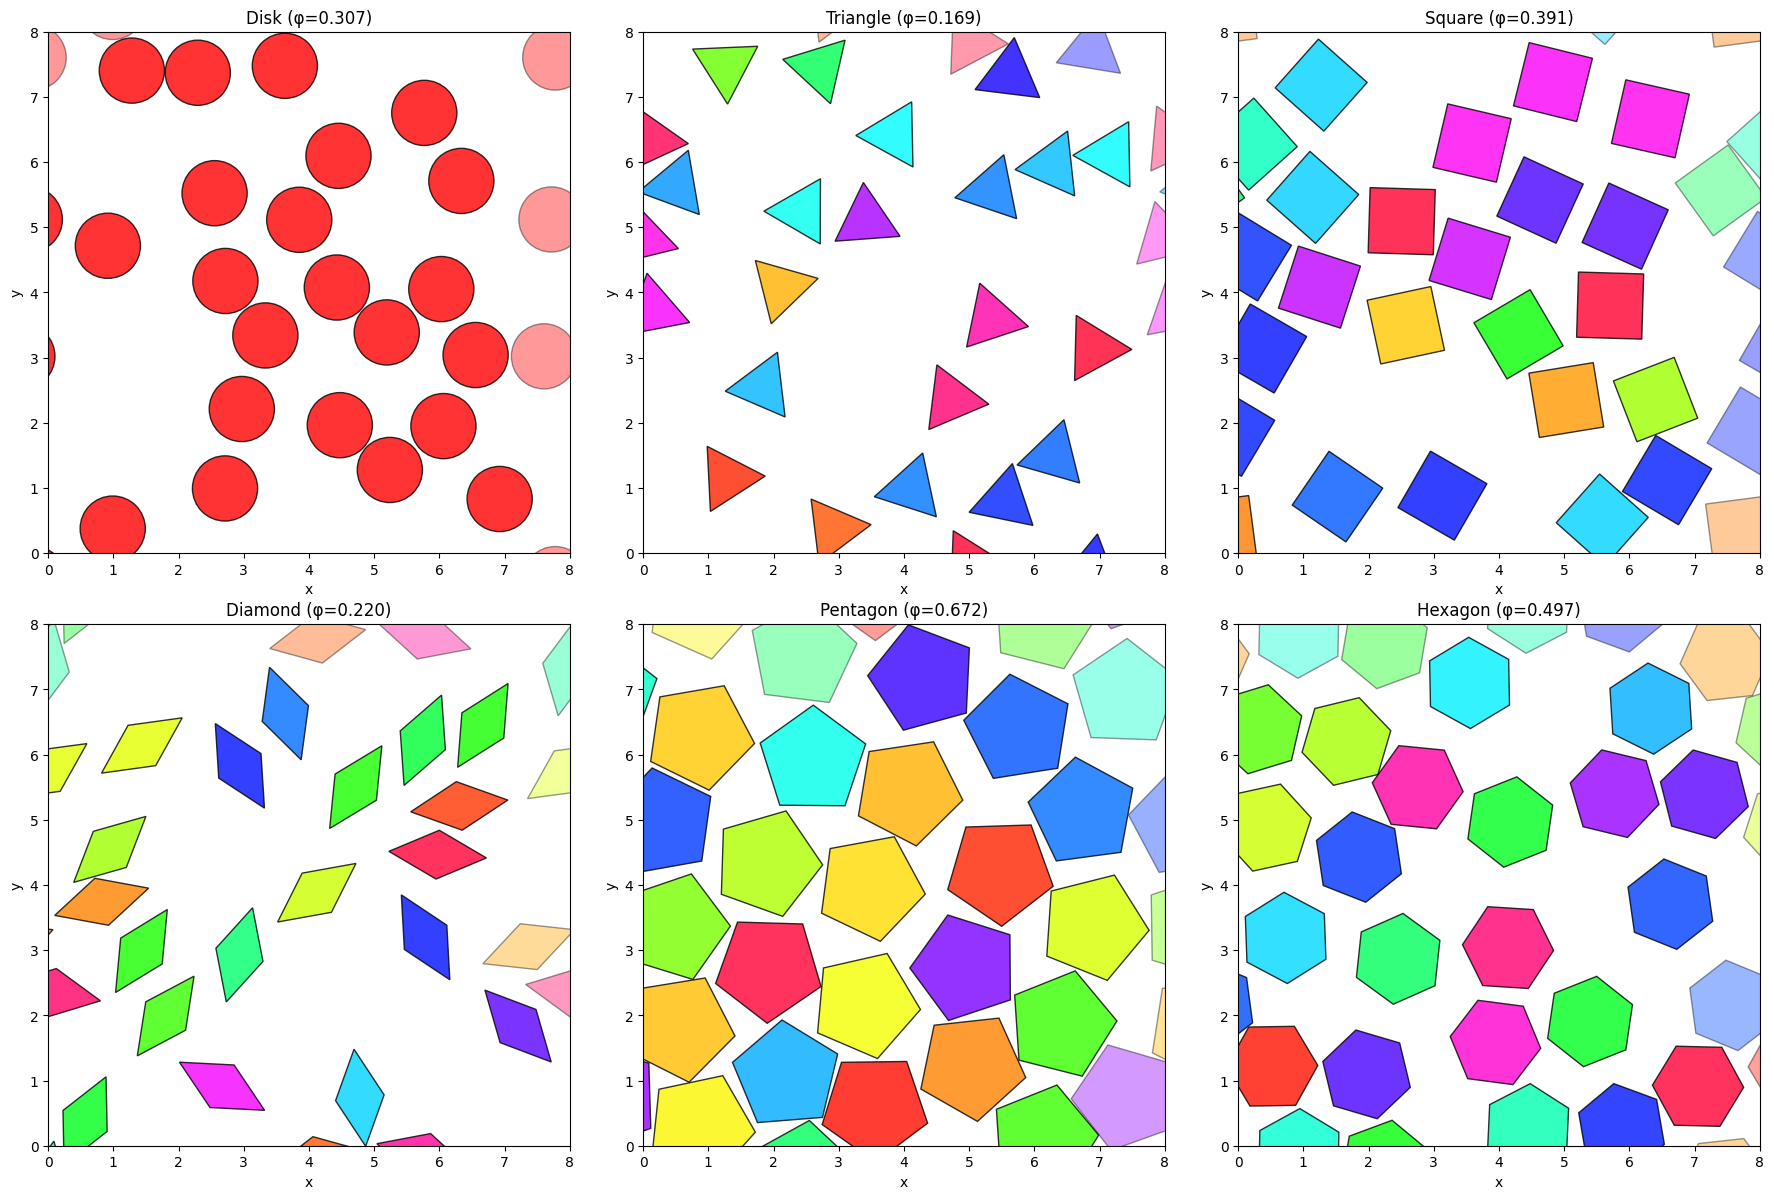


SAVING ALL ANIMATIONS

Saving Disk Simulation GIF
Particles: 25, φ=0.307
Periodic display: True
Filename: disk_periodic.gif

Equilibrating (200 sweeps)...
  Sweep 100/200
  Sweep 200/200

Creating animation (100 frames)...
Saving...

Done! Saved as disk_periodic.gif

Saving Triangle Simulation GIF
Particles: 25, φ=0.169
Periodic display: True
Filename: triangle_periodic.gif

Equilibrating (200 sweeps)...
  Sweep 100/200
  Sweep 200/200

Creating animation (100 frames)...
Saving...

Done! Saved as triangle_periodic.gif

Saving Square Simulation GIF
Particles: 25, φ=0.391
Periodic display: True
Filename: square_periodic.gif

Equilibrating (200 sweeps)...
  Sweep 100/200
  Sweep 200/200

Creating animation (100 frames)...
Saving...

Done! Saved as square_periodic.gif

Saving Diamond Simulation GIF
Particles: 25, φ=0.220
Periodic display: True
Filename: diamond_periodic.gif

Equilibrating (200 sweeps)...
  Sweep 100/200
  Sweep 200/200

Creating animation (100 frames)...
Saving...

Done! 

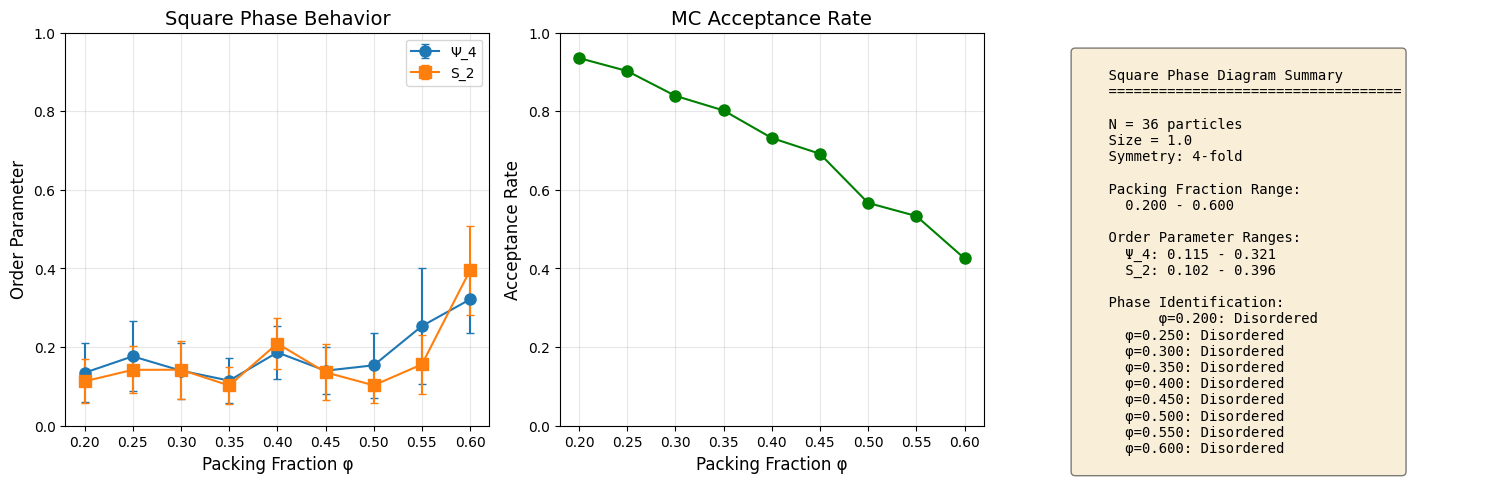


PHASE DIAGRAM SCAN COMPLETE


############################################################
# Scanning Disks
############################################################

PHASE DIAGRAM SCAN: Disks
N = 25, size = 0.5
Packing fractions: [0.25 0.3  0.35 0.4  0.45 0.5  0.55]

φ_target = 0.250, φ_actual = 0.250, L = 8.86
  Equilibrating...
  Avg acceptance: 0.90
  Production run...
  Ψ_1 = 1.000 ± 0.000
  S_2 = 1.000 ± 0.000

φ_target = 0.300, φ_actual = 0.300, L = 8.09
  Equilibrating...
  Avg acceptance: 0.85
  Production run...
  Ψ_1 = 1.000 ± 0.000
  S_2 = 1.000 ± 0.000

φ_target = 0.350, φ_actual = 0.350, L = 7.49
  Equilibrating...
  Avg acceptance: 0.85
  Production run...
  Ψ_1 = 1.000 ± 0.000
  S_2 = 1.000 ± 0.000

φ_target = 0.400, φ_actual = 0.400, L = 7.01
  Equilibrating...
  Avg acceptance: 0.72
  Production run...
  Ψ_1 = 1.000 ± 0.000
  S_2 = 1.000 ± 0.000

φ_target = 0.450, φ_actual = 0.450, L = 6.61
  Equilibrating...
  Avg acceptance: 0.75
  Production run...
  Ψ_1 = 1.00

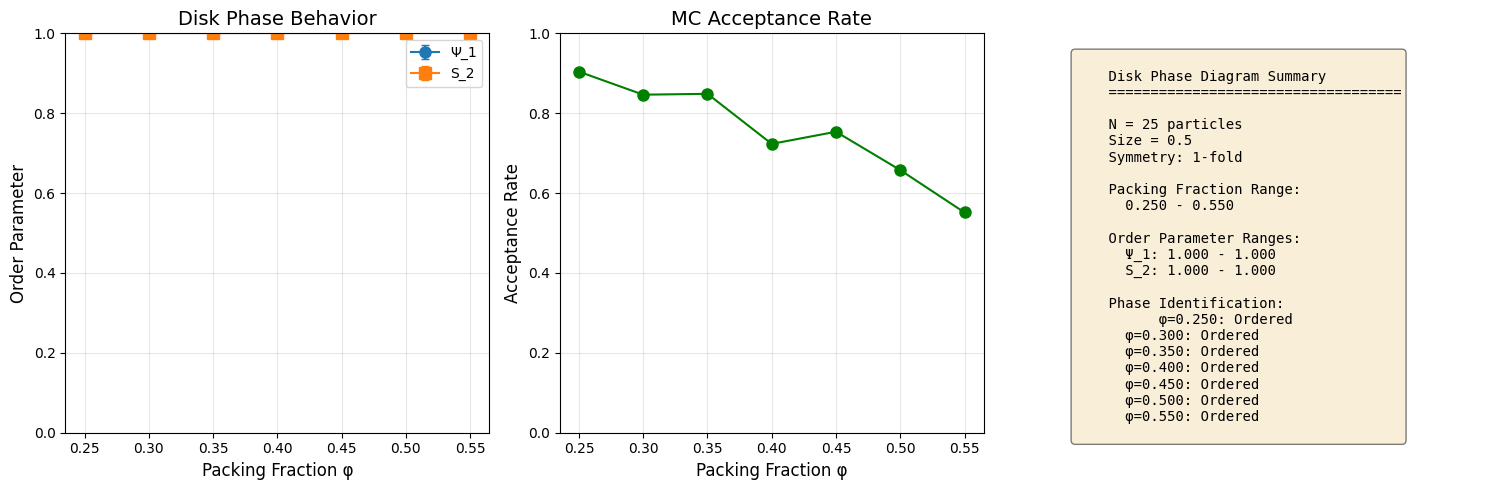


PHASE DIAGRAM SCAN COMPLETE


############################################################
# Scanning Triangles
############################################################

PHASE DIAGRAM SCAN: Triangles
N = 25, size = 1.0
Packing fractions: [0.25 0.3  0.35 0.4  0.45 0.5  0.55]

φ_target = 0.250, φ_actual = 0.250, L = 6.58
  Equilibrating...
  Avg acceptance: 0.83
  Production run...
  Ψ_3 = 0.190 ± 0.148
  S_2 = 0.353 ± 0.094

φ_target = 0.300, φ_actual = 0.300, L = 6.01
  Equilibrating...
  Avg acceptance: 0.70
  Production run...
  Ψ_3 = 0.157 ± 0.066
  S_2 = 0.118 ± 0.039

φ_target = 0.350, φ_actual = 0.350, L = 5.56
  Equilibrating...
  Avg acceptance: 0.63
  Production run...
  Ψ_3 = 0.147 ± 0.070
  S_2 = 0.109 ± 0.045

φ_target = 0.400, φ_actual = 0.400, L = 5.20
  Equilibrating...
  Avg acceptance: 0.56
  Production run...
  Ψ_3 = 0.141 ± 0.051
  S_2 = 0.174 ± 0.069

φ_target = 0.450, φ_actual = 0.450, L = 4.90
  Equilibrating...
  Avg acceptance: 0.49
  Production run...
  Ψ_

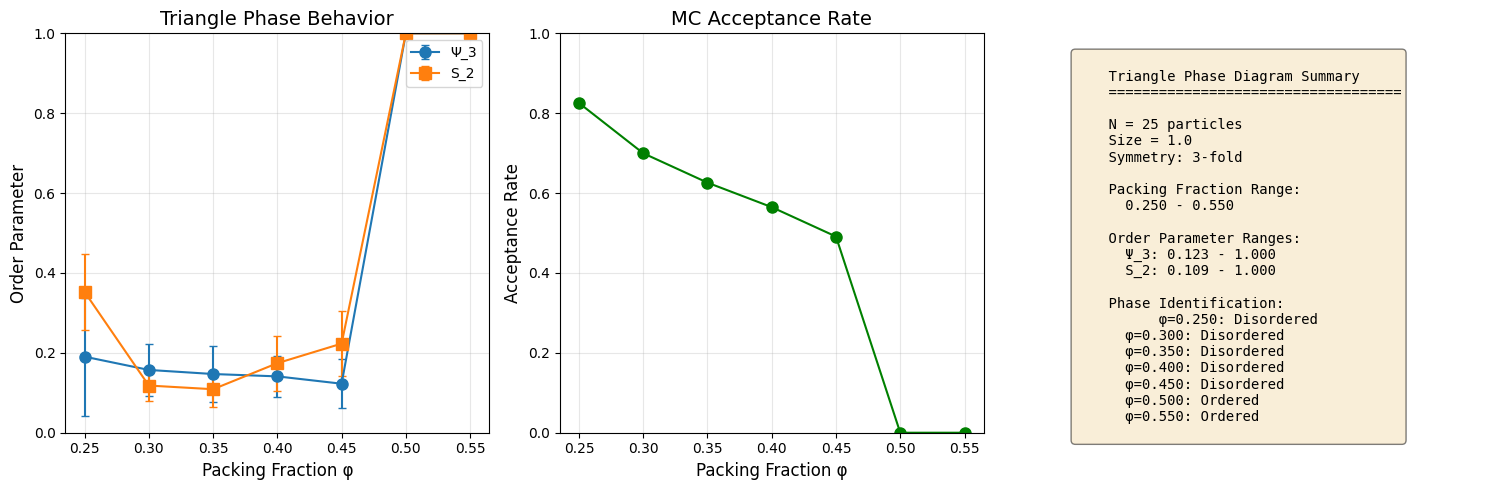


PHASE DIAGRAM SCAN COMPLETE


############################################################
# Scanning Squares
############################################################

PHASE DIAGRAM SCAN: Squares
N = 25, size = 1.0
Packing fractions: [0.25 0.3  0.35 0.4  0.45 0.5  0.55]

φ_target = 0.250, φ_actual = 0.250, L = 10.00
  Equilibrating...
  Avg acceptance: 0.91
  Production run...
  Ψ_4 = 0.160 ± 0.069
  S_2 = 0.190 ± 0.064

φ_target = 0.300, φ_actual = 0.300, L = 9.13
  Equilibrating...
  Avg acceptance: 0.83
  Production run...
  Ψ_4 = 0.172 ± 0.063
  S_2 = 0.097 ± 0.048

φ_target = 0.350, φ_actual = 0.350, L = 8.45
  Equilibrating...
  Avg acceptance: 0.81
  Production run...
  Ψ_4 = 0.155 ± 0.100
  S_2 = 0.158 ± 0.063

φ_target = 0.400, φ_actual = 0.400, L = 7.91
  Equilibrating...
  Avg acceptance: 0.75
  Production run...
  Ψ_4 = 0.258 ± 0.113
  S_2 = 0.098 ± 0.056

φ_target = 0.450, φ_actual = 0.450, L = 7.45
  Equilibrating...
  Avg acceptance: 0.68
  Production run...
  Ψ_4 =

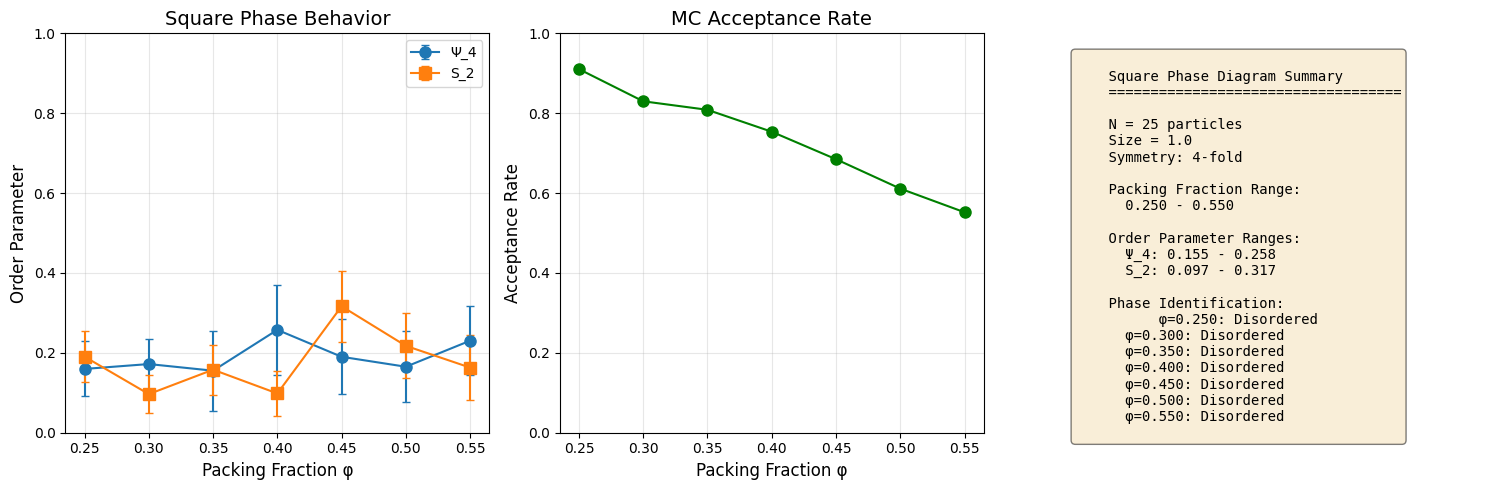


PHASE DIAGRAM SCAN COMPLETE


############################################################
# Scanning Pentagons
############################################################

PHASE DIAGRAM SCAN: Pentagons
N = 25, size = 1.0
Packing fractions: [0.25 0.3  0.35 0.4  0.45 0.5  0.55]

φ_target = 0.250, φ_actual = 0.250, L = 13.12
  Equilibrating...
  Avg acceptance: 0.95
  Production run...
  Ψ_5 = 0.172 ± 0.076
  S_2 = 0.194 ± 0.050

φ_target = 0.300, φ_actual = 0.300, L = 11.97
  Equilibrating...
  Avg acceptance: 0.90
  Production run...
  Ψ_5 = 0.142 ± 0.056
  S_2 = 0.147 ± 0.039

φ_target = 0.350, φ_actual = 0.350, L = 11.09
  Equilibrating...
  Avg acceptance: 0.86
  Production run...
  Ψ_5 = 0.149 ± 0.059
  S_2 = 0.219 ± 0.058

φ_target = 0.400, φ_actual = 0.400, L = 10.37
  Equilibrating...
  Avg acceptance: 0.84
  Production run...
  Ψ_5 = 0.117 ± 0.072
  S_2 = 0.199 ± 0.078

φ_target = 0.450, φ_actual = 0.450, L = 9.78
  Equilibrating...
  Avg acceptance: 0.71
  Production run...


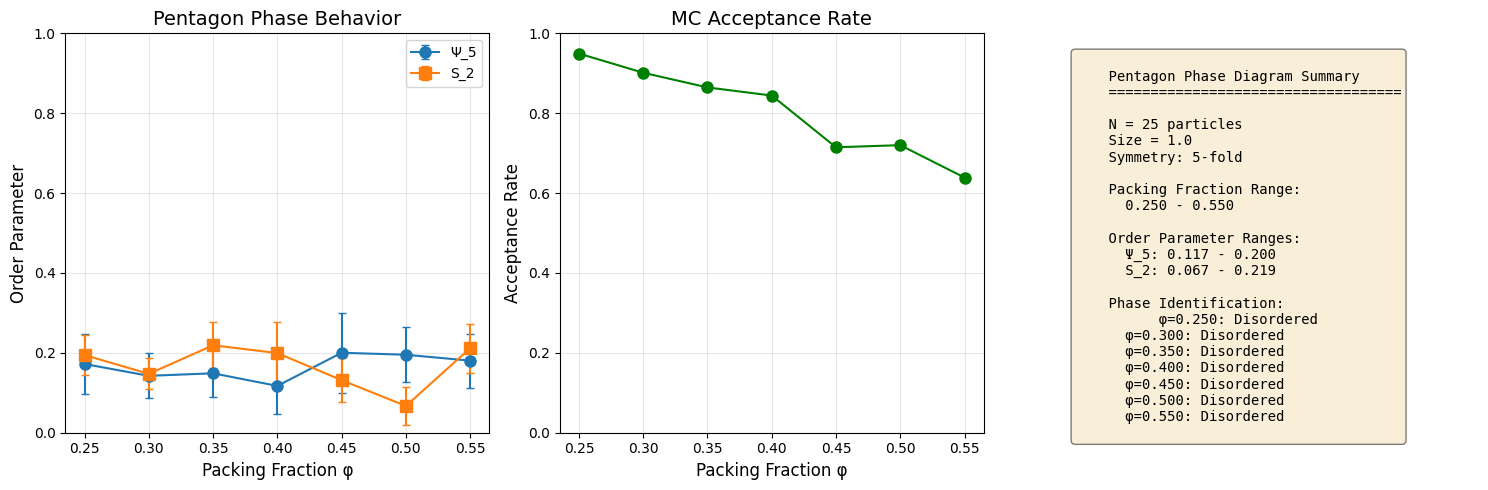


PHASE DIAGRAM SCAN COMPLETE


############################################################
# Scanning Hexagons
############################################################

PHASE DIAGRAM SCAN: Hexagons
N = 25, size = 0.7
Packing fractions: [0.25 0.3  0.35 0.4  0.45 0.5  0.55]

φ_target = 0.250, φ_actual = 0.250, L = 11.28
  Equilibrating...
  Avg acceptance: 0.89
  Production run...
  Ψ_6 = 0.181 ± 0.100
  S_2 = 0.182 ± 0.097

φ_target = 0.300, φ_actual = 0.300, L = 10.30
  Equilibrating...
  Avg acceptance: 0.91
  Production run...
  Ψ_6 = 0.169 ± 0.109
  S_2 = 0.186 ± 0.070

φ_target = 0.350, φ_actual = 0.350, L = 9.54
  Equilibrating...
  Avg acceptance: 0.88
  Production run...
  Ψ_6 = 0.191 ± 0.093
  S_2 = 0.241 ± 0.069

φ_target = 0.400, φ_actual = 0.400, L = 8.92
  Equilibrating...
  Avg acceptance: 0.83
  Production run...
  Ψ_6 = 0.197 ± 0.084
  S_2 = 0.172 ± 0.075

φ_target = 0.450, φ_actual = 0.450, L = 8.41
  Equilibrating...
  Avg acceptance: 0.78
  Production run...
  Ψ_

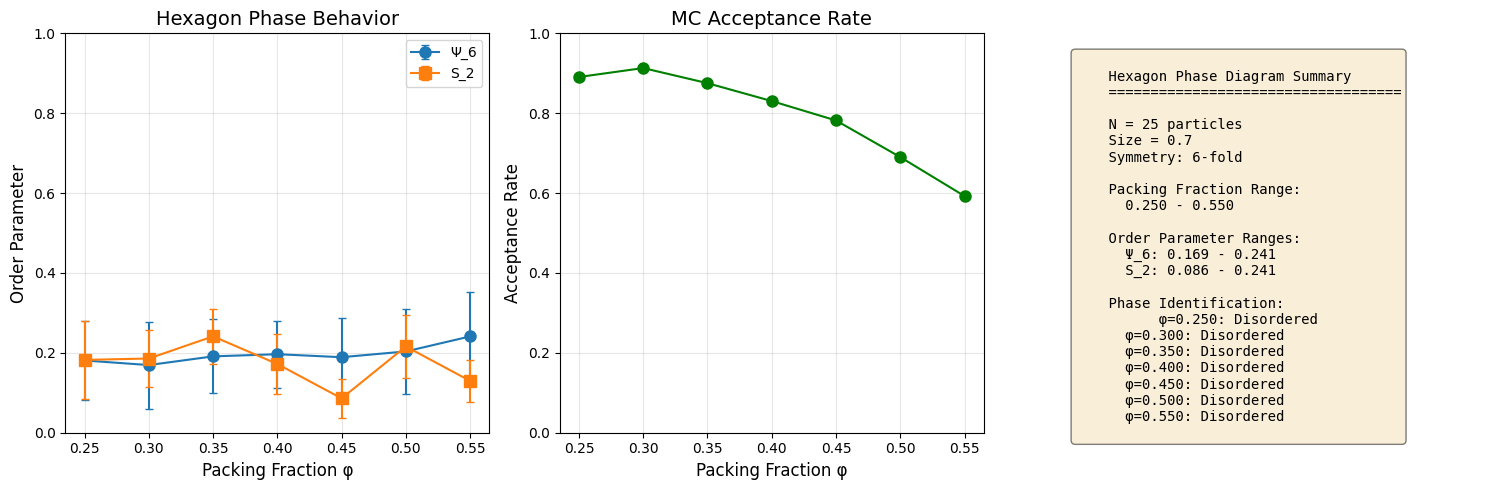


PHASE DIAGRAM SCAN COMPLETE


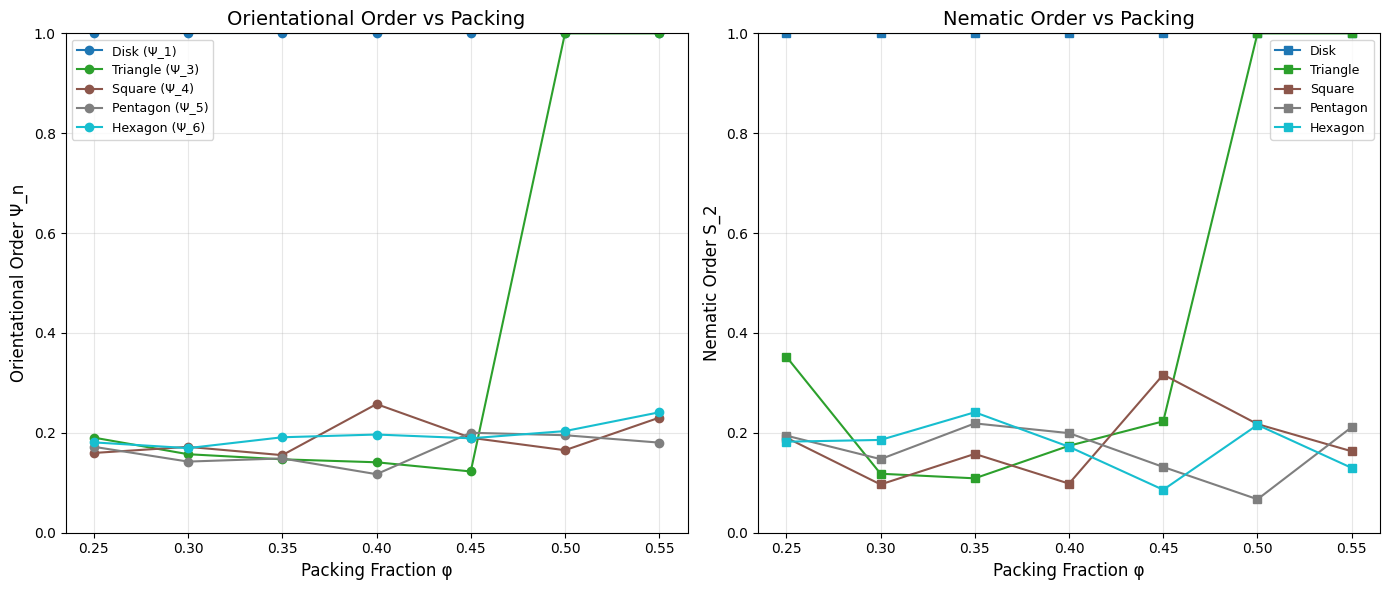

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Polygon, Circle
from scipy.spatial.distance import pdist
import random
from abc import ABC, abstractmethod

# ============================================
# BASE CLASS FOR ALL HARD PARTICLES
# ============================================

class HardParticleSim(ABC):
    """
    Abstract base class for hard particle simulations.
    Subclasses must implement get_vertices() and particle_area().
    """
    
    def __init__(self, N, size, box_size):
        self.N = N
        self.size = size
        self.L = box_size
        self.pos = self._init_grid()
        self.angles = np.zeros(N)
        self.shape_name = "Particle"
        self.n_fold_symmetry = 1
        
    def _init_grid(self):
        """Initialize particles on a grid."""
        grid_size = int(np.ceil(np.sqrt(self.N)))
        spacing = self.L / grid_size
        pos = []
        for i in range(self.N):
            x = (i % grid_size) * spacing + spacing / 2
            y = (i // grid_size) * spacing + spacing / 2
            pos.append([x, y])
        return np.array(pos, dtype=float)
    
    @abstractmethod
    def get_vertices(self, center, angle):
        """Return vertices of the particle. Override in subclasses."""
        pass
    
    @abstractmethod
    def particle_area(self):
        """Return area of a single particle. Override in subclasses."""
        pass
    
    def get_vertices_periodic(self, center, angle):
        """
        Get vertices with periodic boundary handling.
        Returns list of vertex arrays for all visible periodic images.
        """
        vertices = self.get_vertices(center, angle)
        all_images = []
        
        for dx in [-self.L, 0, self.L]:
            for dy in [-self.L, 0, self.L]:
                shifted_vertices = vertices + np.array([dx, dy])
                
                if (np.any(shifted_vertices[:, 0] > 0) and 
                    np.any(shifted_vertices[:, 0] < self.L) and
                    np.any(shifted_vertices[:, 1] > 0) and 
                    np.any(shifted_vertices[:, 1] < self.L)):
                    all_images.append(shifted_vertices)
        
        return all_images
    
    def get_max_extent(self):
        """Get maximum extent of particle from center (for overlap checks)."""
        return self.size * 1.5
    
    def packing_fraction(self):
        """Calculate packing fraction."""
        return self.N * self.particle_area() / self.L**2
    
    def check_overlap(self, idx, new_pos, new_angle):
        """Check if particle idx overlaps with any other particle."""
        verts1 = self.get_vertices(new_pos, new_angle)
        
        max_extent = self.get_max_extent() * 2
        
        for i in range(self.N):
            if i == idx:
                continue
            
            dp = self.pos[i] - new_pos
            dp -= self.L * np.round(dp / self.L)
            
            if np.linalg.norm(dp) > max_extent:
                continue
            
            verts2 = self.get_vertices(new_pos + dp, self.angles[i])
            
            if self._sat_overlap(verts1, verts2):
                return True
        return False
    
    def _sat_overlap(self, v1, v2):
        """Separating Axis Theorem for convex polygons."""
        for verts in [v1, v2]:
            n_verts = len(verts)
            for j in range(n_verts):
                edge = verts[(j + 1) % n_verts] - verts[j]
                normal = np.array([-edge[1], edge[0]])
                
                p1 = v1 @ normal
                p2 = v2 @ normal
                
                if np.max(p1) < np.min(p2) or np.max(p2) < np.min(p1):
                    return False
        return True
    
    def step(self, dr_max=0.1, da_max=0.1):
        """One Monte Carlo sweep."""
        accepted = 0
        for _ in range(self.N):
            idx = random.randint(0, self.N - 1)
            old_p = self.pos[idx].copy()
            old_a = self.angles[idx]
            
            new_p = old_p + (np.random.rand(2) - 0.5) * dr_max
            new_a = old_a + (np.random.rand() - 0.5) * da_max
            new_p %= self.L
            
            if not self.check_overlap(idx, new_p, new_a):
                self.pos[idx] = new_p
                self.angles[idx] = new_a
                accepted += 1
        return accepted / self.N
    
    def radial_distribution_function(self, n_bins=100, r_max=None):
        """Calculate g(r) using center-of-mass distances."""
        if r_max is None:
            r_max = self.L / 2
        
        dr = r_max / n_bins
        bins = np.linspace(0, r_max, n_bins + 1)
        hist = np.zeros(n_bins)
        
        for i in range(self.N):
            for j in range(i + 1, self.N):
                dp = self.pos[j] - self.pos[i]
                dp -= self.L * np.round(dp / self.L)
                r = np.linalg.norm(dp)
                
                if r < r_max:
                    bin_idx = int(r / dr)
                    if bin_idx < n_bins:
                        hist[bin_idx] += 2
        
        r_centers = (bins[:-1] + bins[1:]) / 2
        rho = self.N / self.L**2
        
        g_r = np.zeros(n_bins)
        for i in range(n_bins):
            shell_area = np.pi * ((bins[i+1])**2 - (bins[i])**2)
            ideal_count = rho * shell_area * self.N
            if ideal_count > 0:
                g_r[i] = hist[i] / ideal_count
        
        return r_centers, g_r
    
    def orientational_order_parameter(self, n=None):
        """Calculate n-fold orientational order parameter."""
        if n is None:
            n = self.n_fold_symmetry
        psi_n = np.mean(np.exp(1j * n * self.angles))
        return np.abs(psi_n)
    
    def nematic_order_parameter(self):
        """Calculate S_2 nematic order parameter."""
        Q = np.zeros((2, 2))
        for angle in self.angles:
            n = np.array([np.cos(angle), np.sin(angle)])
            Q += np.outer(n, n) - 0.5 * np.eye(2)
        Q /= self.N
        
        eigenvalues = np.linalg.eigvalsh(Q)
        S2 = 2 * np.max(np.abs(eigenvalues))
        return S2
    
    def spatial_correlation_function(self, n_bins=50, r_max=None, n=None):
        """Calculate orientational correlation function."""
        if r_max is None:
            r_max = self.L / 2
        if n is None:
            n = self.n_fold_symmetry
        
        dr = r_max / n_bins
        bins = np.linspace(0, r_max, n_bins + 1)
        
        correlation = np.zeros(n_bins)
        counts = np.zeros(n_bins)
        
        for i in range(self.N):
            for j in range(i + 1, self.N):
                dp = self.pos[j] - self.pos[i]
                dp -= self.L * np.round(dp / self.L)
                r = np.linalg.norm(dp)
                
                if r < r_max:
                    bin_idx = int(r / dr)
                    if bin_idx < n_bins:
                        delta_angle = self.angles[j] - self.angles[i]
                        correlation[bin_idx] += np.cos(n * delta_angle)
                        counts[bin_idx] += 1
        
        with np.errstate(divide='ignore', invalid='ignore'):
            g_n_r = np.where(counts > 0, correlation / counts, 0)
        
        r_centers = (bins[:-1] + bins[1:]) / 2
        return r_centers, g_n_r
    
    def angle_distribution(self, n_bins=36):
        """Get histogram of particle orientations."""
        symmetry_period = 2 * np.pi / max(self.n_fold_symmetry, 1)
        normalized_angles = self.angles % symmetry_period
        hist, bin_edges = np.histogram(normalized_angles, bins=n_bins,
                                       range=(0, symmetry_period))
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        return bin_centers, hist / self.N
    
    def save_gif(self, filename='simulation.gif', n_frames=100,
                 sweeps_per_frame=5, fps=20, dr_max=0.3, da_max=0.4,
                 equilibrate=200, colorby='orientation', show_periodic=True,
                 show_order=True):
        
        phi = self.packing_fraction()
        n = self.n_fold_symmetry
        symmetry_period = 2 * np.pi / max(n, 1)
        
        print(f"\n{'='*50}")
        print(f"Saving {self.shape_name} Simulation GIF")
        print(f"{'='*50}")
        print(f"Particles: {self.N}, φ={phi:.3f}")
        print(f"Periodic display: {show_periodic}")
        print(f"Filename: {filename}")
        print(f"{'='*50}")
        
        if equilibrate > 0:
            print(f"\nEquilibrating ({equilibrate} sweeps)...")
            for i in range(equilibrate):
                self.step(dr_max=dr_max, da_max=da_max)
                if (i + 1) % 100 == 0:
                    print(f"  Sweep {i+1}/{equilibrate}")
        
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.set_xlim(0, self.L)
        ax.set_ylim(0, self.L)
        ax.set_aspect('equal')
        ax.set_facecolor('#f8f8f8')
        
        if colorby == 'index':
            base_colors = plt.cm.viridis(np.linspace(0, 1, self.N))
        else:
            base_colors = plt.cm.hsv(self.angles % symmetry_period / symmetry_period)
        
        particle_patches = {}
        
        def create_patches():
            for idx in list(particle_patches.keys()):
                for patch in particle_patches[idx]:
                    patch.remove()
            particle_patches.clear()
            
            for i in range(self.N):
                if colorby == 'orientation':
                    color = plt.cm.hsv((self.angles[i] % symmetry_period) / symmetry_period)
                else:
                    color = base_colors[i]
                
                particle_patches[i] = []
                
                if show_periodic:
                    all_vertices = self.get_vertices_periodic(self.pos[i], self.angles[i])
                    for j, vertices in enumerate(all_vertices):
                        alpha = 0.8 if j == 0 or len(all_vertices) == 1 else 0.5
                        
                        if isinstance(self, HardDiskSim):
                            center = np.mean(vertices, axis=0)
                            patch = Circle(center, self.radius,
                                         facecolor=color, edgecolor='black',
                                         alpha=alpha, linewidth=1)
                        else:
                            patch = Polygon(vertices, closed=True,
                                          facecolor=color, edgecolor='black',
                                          alpha=alpha, linewidth=1)
                        ax.add_patch(patch)
                        particle_patches[i].append(patch)
                else:
                    if isinstance(self, HardDiskSim):
                        patch = Circle(self.pos[i], self.radius,
                                     facecolor=color, edgecolor='black',
                                     alpha=0.8, linewidth=1)
                    else:
                        vertices = self.get_vertices(self.pos[i], self.angles[i])
                        patch = Polygon(vertices, closed=True,
                                      facecolor=color, edgecolor='black',
                                      alpha=0.8, linewidth=1)
                    ax.add_patch(patch)
                    particle_patches[i].append(patch)
        
        create_patches()
        
        title = ax.set_title(f'{self.shape_name}s | N={self.N} | φ={phi:.3f} | Sweep: 0',
                            fontsize=12, fontweight='bold')
        
        if show_order:
            psi = self.orientational_order_parameter()
            order_text = ax.text(0.02, 0.98, f'Ψ_{n} = {psi:.3f}',
                                transform=ax.transAxes, fontsize=10,
                                verticalalignment='top',
                                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        def animate(frame):
            for _ in range(sweeps_per_frame):
                self.step(dr_max=dr_max, da_max=da_max)
            
            create_patches()
            
            sweep_num = frame * sweeps_per_frame
            title.set_text(f'{self.shape_name}s | N={self.N} | φ={phi:.3f} | Sweep: {sweep_num}')
            
            if show_order:
                psi = self.orientational_order_parameter()
                order_text.set_text(f'Ψ_{n} = {psi:.3f}')
            
            all_patches = []
            for patches in particle_patches.values():
                all_patches.extend(patches)
            
            if show_order:
                return all_patches + [title, order_text]
            return all_patches + [title]
        
        print(f"\nCreating animation ({n_frames} frames)...")
        anim = animation.FuncAnimation(fig, animate, frames=n_frames,
                                       interval=1000/fps, blit=False)
        
        print(f"Saving...")
        anim.save(filename, writer='pillow', fps=fps)
        
        print(f"\nDone! Saved as {filename}")
        plt.close()
        
        return filename


class HardDiskSim(HardParticleSim):
    """Hard disk (circle) simulation."""
    
    def __init__(self, N, radius, box_size):
        self.radius = radius
        super().__init__(N, radius, box_size)
        self.shape_name = "Disk"
        self.n_fold_symmetry = 1
    
    def get_vertices(self, center, angle, n_points=32):
        """Return points on circle perimeter for visualization."""
        theta = np.linspace(0, 2*np.pi, n_points, endpoint=False)
        vertices = np.zeros((n_points, 2))
        vertices[:, 0] = center[0] + self.radius * np.cos(theta)
        vertices[:, 1] = center[1] + self.radius * np.sin(theta)
        return vertices
    
    def get_max_extent(self):
        return self.radius
    
    def particle_area(self):
        return np.pi * self.radius**2
    
    def check_overlap(self, idx, new_pos, new_angle):
        """Simple distance-based overlap for circles."""
        for i in range(self.N):
            if i == idx:
                continue
            
            dp = self.pos[i] - new_pos
            dp -= self.L * np.round(dp / self.L)
            dist = np.linalg.norm(dp)
            
            if dist < 2 * self.radius:
                return True
        return False
    
    def step(self, dr_max=0.1, da_max=0.0):
        """Monte Carlo sweep (no rotation for circles)."""
        accepted = 0
        for _ in range(self.N):
            idx = random.randint(0, self.N - 1)
            old_p = self.pos[idx].copy()
            
            new_p = old_p + (np.random.rand(2) - 0.5) * dr_max
            new_p %= self.L
            
            if not self.check_overlap(idx, new_p, 0):
                self.pos[idx] = new_p
                accepted += 1
        return accepted / self.N


class HardTriangleSim(HardParticleSim):
    """Hard equilateral triangle simulation."""
    
    def __init__(self, N, side_length, box_size):
        super().__init__(N, side_length, box_size)
        self.shape_name = "Triangle"
        self.n_fold_symmetry = 3
    
    def get_vertices(self, center, angle):
        """Return 3 vertices of equilateral triangle."""
        r = self.size / np.sqrt(3)
        vertices = np.zeros((3, 2))
        for i in range(3):
            theta = angle + i * 2 * np.pi / 3
            vertices[i, 0] = center[0] + r * np.cos(theta)
            vertices[i, 1] = center[1] + r * np.sin(theta)
        return vertices
    
    def get_max_extent(self):
        return self.size / np.sqrt(3)
    
    def particle_area(self):
        return (np.sqrt(3) / 4) * self.size**2


class HardSquareSim(HardParticleSim):
    """Hard square simulation."""
    
    def __init__(self, N, side_length, box_size):
        super().__init__(N, side_length, box_size)
        self.shape_name = "Square"
        self.n_fold_symmetry = 4
    
    def get_vertices(self, center, angle):
        """Return 4 vertices of square."""
        s, c = np.sin(angle), np.cos(angle)
        R = np.array([[c, -s], [s, c]])
        half = self.size / 2
        corners = np.array([[-half, -half], [half, -half],
                           [half, half], [-half, half]])
        return center + corners @ R.T
    
    def get_max_extent(self):
        return self.size * np.sqrt(2) / 2
    
    def particle_area(self):
        return self.size**2


class HardDiamondSim(HardParticleSim):
    """Hard diamond (rhombus) simulation."""
    
    def __init__(self, N, diagonal1, box_size, aspect_ratio=0.5):
        self.diagonal1 = diagonal1
        self.diagonal2 = diagonal1 * aspect_ratio
        self.aspect_ratio = aspect_ratio
        super().__init__(N, diagonal1, box_size)
        self.shape_name = "Diamond"
        self.n_fold_symmetry = 2
    
    def get_vertices(self, center, angle):
        """Return 4 vertices of diamond."""
        s, c = np.sin(angle), np.cos(angle)
        R = np.array([[c, -s], [s, c]])
        
        half_d1 = self.diagonal1 / 2
        half_d2 = self.diagonal2 / 2
        
        corners = np.array([
            [half_d1, 0],
            [0, half_d2],
            [-half_d1, 0],
            [0, -half_d2]
        ])
        
        return center + corners @ R.T
    
    def get_max_extent(self):
        return self.diagonal1 / 2
    
    def particle_area(self):
        return 0.5 * self.diagonal1 * self.diagonal2


class HardPentagonSim(HardParticleSim):
    """Hard regular pentagon simulation."""
    
    def __init__(self, N, side_length, box_size):
        super().__init__(N, side_length, box_size)
        self.shape_name = "Pentagon"
        self.n_fold_symmetry = 5
        self.circumradius = self.size / (2 * np.sin(np.pi / 5))
    
    def get_vertices(self, center, angle):
        """Return 5 vertices of regular pentagon."""
        r = self.circumradius
        vertices = np.zeros((5, 2))
        for i in range(5):
            theta = angle + i * 2 * np.pi / 5 - np.pi / 2
            vertices[i, 0] = center[0] + r * np.cos(theta)
            vertices[i, 1] = center[1] + r * np.sin(theta)
        return vertices
    
    def get_max_extent(self):
        return self.circumradius
    
    def particle_area(self):
        return (self.size**2 / 4) * np.sqrt(25 + 10 * np.sqrt(5))


class HardHexagonSim(HardParticleSim):
    """Hard regular hexagon simulation."""
    
    def __init__(self, N, side_length, box_size):
        super().__init__(N, side_length, box_size)
        self.shape_name = "Hexagon"
        self.n_fold_symmetry = 6
    
    def get_vertices(self, center, angle):
        """Return 6 vertices of regular hexagon."""
        r = self.size
        vertices = np.zeros((6, 2))
        for i in range(6):
            theta = angle + i * np.pi / 3
            vertices[i, 0] = center[0] + r * np.cos(theta)
            vertices[i, 1] = center[1] + r * np.sin(theta)
        return vertices
    
    def get_max_extent(self):
        return self.size
    
    def particle_area(self):
        return (3 * np.sqrt(3) / 2) * self.size**2


# ============================================
# VISUALIZATION FUNCTIONS
# ============================================

def visualize_configuration(sim, ax=None, title=None, show_periodic=True):
    """Visualize current configuration with periodic boundaries."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    phi = sim.packing_fraction()
    n = max(sim.n_fold_symmetry, 1)
    symmetry_period = 2 * np.pi / n
    
    colors = plt.cm.hsv(sim.angles % symmetry_period / symmetry_period)
    
    for i in range(sim.N):
        if show_periodic:
            all_vertices = sim.get_vertices_periodic(sim.pos[i], sim.angles[i])
            for j, vertices in enumerate(all_vertices):
                alpha = 0.8 if j == 0 or len(all_vertices) == 1 else 0.4
                
                if isinstance(sim, HardDiskSim):
                    center = np.mean(vertices, axis=0)
                    patch = Circle(center, sim.radius,
                                 facecolor=colors[i], edgecolor='black', alpha=alpha)
                else:
                    patch = Polygon(vertices, closed=True,
                                  facecolor=colors[i], edgecolor='black', alpha=alpha)
                ax.add_patch(patch)
        else:
            if isinstance(sim, HardDiskSim):
                patch = Circle(sim.pos[i], sim.radius,
                             facecolor=colors[i], edgecolor='black', alpha=0.8)
            else:
                vertices = sim.get_vertices(sim.pos[i], sim.angles[i])
                patch = Polygon(vertices, closed=True,
                              facecolor=colors[i], edgecolor='black', alpha=0.8)
            ax.add_patch(patch)
    
    ax.set_xlim(0, sim.L)
    ax.set_ylim(0, sim.L)
    ax.set_aspect('equal')
    
    if title is None:
        title = f'{sim.shape_name}s (N={sim.N}, φ={phi:.3f})'
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    
    return ax


def run_and_analyze(sim, equilibration_sweeps=500, production_sweeps=500,
                    dr_max=0.3, da_max=0.4):
    """Run simulation and perform structural analysis."""
    
    phi = sim.packing_fraction()
    n = sim.n_fold_symmetry
    
    print(f"=" * 50)
    print(f"Hard {sim.shape_name} Simulation")
    print(f"=" * 50)
    print(f"N = {sim.N}, size = {sim.size}, L = {sim.L}")
    print(f"Packing fraction φ = {phi:.3f}")
    print(f"Symmetry: {n}-fold")
    print(f"=" * 50)
    
    print("\nEquilibrating...")
    for i in range(equilibration_sweeps):
        acc = sim.step(dr_max=dr_max, da_max=da_max)
        if i % 100 == 0:
            print(f"  Sweep {i}, acceptance = {acc:.2f}")
    
    print("\nProduction run...")
    g_r_samples = []
    psi_n_samples = []
    S2_samples = []
    g_n_r_samples = []
    
    for i in range(production_sweeps):
        sim.step(dr_max=dr_max, da_max=da_max)
        
        if i % 10 == 0:
            r, g_r = sim.radial_distribution_function()
            g_r_samples.append(g_r)
            
            psi_n_samples.append(sim.orientational_order_parameter())
            S2_samples.append(sim.nematic_order_parameter())
            
            r_corr, g_n_r = sim.spatial_correlation_function()
            g_n_r_samples.append(g_n_r)
        
        if i % 100 == 0:
            print(f"  Sweep {i}")
    
    g_r_avg = np.mean(g_r_samples, axis=0)
    g_n_r_avg = np.mean(g_n_r_samples, axis=0)
    psi_n_avg = np.mean(psi_n_samples)
    psi_n_std = np.std(psi_n_samples)
    S2_avg = np.mean(S2_samples)
    S2_std = np.std(S2_samples)
    
    angle_bins, angle_hist = sim.angle_distribution()
    
    print(f"\n" + "=" * 50)
    print("RESULTS")
    print(f"=" * 50)
    print(f"Ψ_{n} = {psi_n_avg:.3f} ± {psi_n_std:.3f}")
    print(f"S_2 = {S2_avg:.3f} ± {S2_std:.3f}")
    print(f"=" * 50)
    
    fig = plt.figure(figsize=(16, 12))
    
    ax1 = fig.add_subplot(2, 3, 1)
    visualize_configuration(sim, ax1, show_periodic=True)
    
    ax2 = fig.add_subplot(2, 3, 2)
    ax2.plot(r, g_r_avg, 'b-', linewidth=2)
    ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax2.set_xlabel('r')
    ax2.set_ylabel('g(r)')
    ax2.set_title('Radial Distribution Function')
    ax2.set_xlim(0, sim.L/2)
    
    ax3 = fig.add_subplot(2, 3, 3)
    ax3.plot(r_corr, g_n_r_avg, 'g-', linewidth=2)
    ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax3.set_xlabel('r')
    ax3.set_ylabel(f'g_{n}(r)')
    ax3.set_title(f'{n}-fold Orientational Correlation')
    ax3.set_xlim(0, sim.L/2)
    
    ax4 = fig.add_subplot(2, 3, 4)
    ax4.bar(np.degrees(angle_bins), angle_hist,
            width=360/max(n,1)/len(angle_bins)*0.8, color='purple', alpha=0.7)
    ax4.set_xlabel(f'Orientation (degrees)')
    ax4.set_ylabel('Probability')
    ax4.set_title(f'Angle Distribution\nΨ_{n} = {psi_n_avg:.3f}')
    
    ax5 = fig.add_subplot(2, 3, 5)
    ax5.plot(psi_n_samples, 'b-', alpha=0.7, label=f'Ψ_{n}')
    ax5.plot(S2_samples, 'r-', alpha=0.7, label='S_2')
    ax5.set_xlabel('Sample')
    ax5.set_ylabel('Order Parameter')
    ax5.set_title('Order Parameters vs Time')
    ax5.legend()
    ax5.set_ylim(0, 1)
    
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.axis('off')
    info_text = f"""
    Shape: {sim.shape_name}
    Particles: {sim.N}
    Box: {sim.L} × {sim.L}
    Packing: φ = {phi:.3f}
    Symmetry: {n}-fold
    
    Results:
    Ψ_{n} = {psi_n_avg:.3f} ± {psi_n_std:.3f}
    S_2 = {S2_avg:.3f} ± {S2_std:.3f}
    """
    ax6.text(0.1, 0.5, info_text, transform=ax6.transAxes,
             fontsize=12, verticalalignment='center', fontfamily='monospace')
    
    plt.tight_layout()
    plt.savefig(f'{sim.shape_name.lower()}_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return {
        'phi': phi,
        f'psi_{n}': psi_n_avg,
        'S2': S2_avg,
        'r': r,
        'g_r': g_r_avg
    }


def compare_all_shapes(N=25, size=1.0, box_size=8.0, sweeps=300):
    """Compare all particle shapes."""
    shapes = {
        'Disk': HardDiskSim(N, size/2, box_size),
        'Triangle': HardTriangleSim(N, size, box_size),
        'Square': HardSquareSim(N, size, box_size),
        'Diamond': HardDiamondSim(N, size*1.5, box_size, aspect_ratio=0.5),
        'Pentagon': HardPentagonSim(N, size, box_size),
        'Hexagon': HardHexagonSim(N, size*0.7, box_size),
    }
    
    results = {}
    
    print("Equilibrating all shapes...")
    for name, sim in shapes.items():
        print(f"  {name}...")
        for _ in range(300):
            sim.step(dr_max=0.3, da_max=0.4)
    
    print("\nProduction runs...")
    for name, sim in shapes.items():
        print(f"  {name}...")
        psi_vals = []
        S2_vals = []
        
        for _ in range(sweeps):
            sim.step(dr_max=0.3, da_max=0.4)
            psi_vals.append(sim.orientational_order_parameter())
            S2_vals.append(sim.nematic_order_parameter())
        
        r, g_r = sim.radial_distribution_function()
        
        results[name] = {
            'sim': sim,
            'phi': sim.packing_fraction(),
            'psi': np.mean(psi_vals),
            'psi_std': np.std(psi_vals),
            'S2': np.mean(S2_vals),
            'r': r,
            'g_r': g_r
        }
    
    fig = plt.figure(figsize=(18, 12))
    
    for i, (name, data) in enumerate(results.items()):
        ax = fig.add_subplot(2, 3, i + 1)
        visualize_configuration(data['sim'], ax,
                               title=f"{name} (φ={data['phi']:.3f})",
                               show_periodic=True)
    
    plt.tight_layout()
    plt.savefig('all_shapes_configurations.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return results


def save_all_gifs(equilibrate=200, n_frames=100):
    """Save GIFs for all particle shapes."""
    shapes = [
        ('disk', HardDiskSim(25, 0.5, 8.0)),
        ('triangle', HardTriangleSim(25, 1.0, 8.0)),
        ('square', HardSquareSim(25, 1.0, 8.0)),
        ('diamond', HardDiamondSim(25, 1.5, 8.0, 0.5)),
        ('pentagon', HardPentagonSim(25, 1.0, 9.0)),
        ('hexagon', HardHexagonSim(25, 0.8, 9.0)),
    ]
    
    for name, sim in shapes:
        sim.save_gif(
            filename=f'{name}_periodic.gif',
            n_frames=n_frames,
            sweeps_per_frame=5,
            fps=20,
            equilibrate=equilibrate,
            show_periodic=True
        )


# ============================================
# PHASE DIAGRAM SCAN FUNCTION (MISSING)
# ============================================

def phase_diagram_scan(shape_class=None, N=36, size=1.0, 
                       phi_values=None, equilibrate=300, 
                       production=200, dr_max=0.3, da_max=0.4):
    """
    Scan packing fractions to map out phase behavior.
    
    Parameters:
    -----------
    shape_class : class, optional
        Particle shape class (default: HardSquareSim)
    N : int
        Number of particles
    size : float
        Particle size parameter
    phi_values : array-like, optional
        Packing fractions to scan
    equilibrate : int
        Equilibration sweeps
    production : int
        Production sweeps for averaging
    
    Returns:
    --------
    dict : Results containing phi, order parameters, etc.
    """
    
    if shape_class is None:
        shape_class = HardSquareSim
    
    if phi_values is None:
        phi_values = np.linspace(0.2, 0.6, 9)
    
    results = {
        'phi': [],
        'phi_actual': [],
        'psi': [],
        'psi_std': [],
        'S2': [],
        'S2_std': [],
        'acceptance': []
    }
    
    # Get shape name for printing
    temp_sim = shape_class(4, size, 10.0)
    shape_name = temp_sim.shape_name
    n_symmetry = temp_sim.n_fold_symmetry
    
    print(f"\n{'='*60}")
    print(f"PHASE DIAGRAM SCAN: {shape_name}s")
    print(f"{'='*60}")
    print(f"N = {N}, size = {size}")
    print(f"Packing fractions: {phi_values}")
    print(f"{'='*60}")
    
    for phi_target in phi_values:
        # Calculate box size for target packing fraction
        particle_area = temp_sim.particle_area()
        box_size = np.sqrt(N * particle_area / phi_target)
        
        # Create simulation
        sim = shape_class(N, size, box_size)
        phi_actual = sim.packing_fraction()
        
        print(f"\nφ_target = {phi_target:.3f}, φ_actual = {phi_actual:.3f}, L = {box_size:.2f}")
        
        # Equilibration
        print(f"  Equilibrating...")
        acc_list = []
        for i in range(equilibrate):
            acc = sim.step(dr_max=dr_max, da_max=da_max)
            if i >= equilibrate // 2:
                acc_list.append(acc)
        
        avg_acc = np.mean(acc_list) if acc_list else 0
        print(f"  Avg acceptance: {avg_acc:.2f}")
        
        # Production
        print(f"  Production run...")
        psi_samples = []
        S2_samples = []
        
        for i in range(production):
            sim.step(dr_max=dr_max, da_max=da_max)
            if i % 5 == 0:
                psi_samples.append(sim.orientational_order_parameter())
                S2_samples.append(sim.nematic_order_parameter())
        
        # Store results
        results['phi'].append(phi_target)
        results['phi_actual'].append(phi_actual)
        results['psi'].append(np.mean(psi_samples))
        results['psi_std'].append(np.std(psi_samples))
        results['S2'].append(np.mean(S2_samples))
        results['S2_std'].append(np.std(S2_samples))
        results['acceptance'].append(avg_acc)
        
        print(f"  Ψ_{n_symmetry} = {results['psi'][-1]:.3f} ± {results['psi_std'][-1]:.3f}")
        print(f"  S_2 = {results['S2'][-1]:.3f} ± {results['S2_std'][-1]:.3f}")
    
    # Convert to arrays
    for key in results:
        results[key] = np.array(results[key])
    
    # Plot results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Order parameters vs packing fraction
    ax1 = axes[0]
    ax1.errorbar(results['phi_actual'], results['psi'], 
                 yerr=results['psi_std'], fmt='o-', 
                 label=f'Ψ_{n_symmetry}', capsize=3, markersize=8)
    ax1.errorbar(results['phi_actual'], results['S2'], 
                 yerr=results['S2_std'], fmt='s-', 
                 label='S_2', capsize=3, markersize=8)
    ax1.set_xlabel('Packing Fraction φ', fontsize=12)
    ax1.set_ylabel('Order Parameter', fontsize=12)
    ax1.set_title(f'{shape_name} Phase Behavior', fontsize=14)
    ax1.legend(fontsize=10)
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)
    
    # Acceptance rate
    ax2 = axes[1]
    ax2.plot(results['phi_actual'], results['acceptance'], 'go-', markersize=8)
    ax2.set_xlabel('Packing Fraction φ', fontsize=12)
    ax2.set_ylabel('Acceptance Rate', fontsize=12)
    ax2.set_title('MC Acceptance Rate', fontsize=14)
    ax2.set_ylim(0, 1)
    ax2.grid(True, alpha=0.3)
    
    # Phase diagram summary
    ax3 = axes[2]
    ax3.axis('off')
    
    # Identify phases based on order parameters
    summary_text = f"""
    {shape_name} Phase Diagram Summary
    {'='*35}
    
    N = {N} particles
    Size = {size}
    Symmetry: {n_symmetry}-fold
    
    Packing Fraction Range:
      {results['phi_actual'].min():.3f} - {results['phi_actual'].max():.3f}
    
    Order Parameter Ranges:
      Ψ_{n_symmetry}: {results['psi'].min():.3f} - {results['psi'].max():.3f}
      S_2: {results['S2'].min():.3f} - {results['S2'].max():.3f}
    
    Phase Identification:
    """
    
    # Simple phase identification
    for i, phi in enumerate(results['phi_actual']):
        psi = results['psi'][i]
        S2 = results['S2'][i]
        
        if psi > 0.7 and S2 > 0.7:
            phase = "Ordered"
        elif psi > 0.4 or S2 > 0.4:
            phase = "Partially Ordered"
        else:
            phase = "Disordered"
        
        summary_text += f"      φ={phi:.3f}: {phase}\n"
    
    ax3.text(0.05, 0.95, summary_text, transform=ax3.transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(f'{shape_name.lower()}_phase_diagram.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n{'='*60}")
    print("PHASE DIAGRAM SCAN COMPLETE")
    print(f"{'='*60}")
    
    return results


def scan_multiple_shapes(shapes=None, N=36, phi_values=None, **kwargs):
    """
    Scan phase behavior for multiple shapes.
    
    Parameters:
    -----------
    shapes : dict, optional
        Dictionary of {name: (class, size)} pairs
    N : int
        Number of particles
    phi_values : array-like
        Packing fractions to scan
    
    Returns:
    --------
    dict : Results for each shape
    """
    
    if shapes is None:
        shapes = {
            'Disk': (HardDiskSim, 0.5),
            'Triangle': (HardTriangleSim, 1.0),
            'Square': (HardSquareSim, 1.0),
            'Pentagon': (HardPentagonSim, 1.0),
            'Hexagon': (HardHexagonSim, 0.7),
        }
    
    if phi_values is None:
        phi_values = np.linspace(0.25, 0.55, 7)
    
    all_results = {}
    
    for name, (shape_class, size) in shapes.items():
        print(f"\n\n{'#'*60}")
        print(f"# Scanning {name}s")
        print(f"{'#'*60}")
        
        all_results[name] = phase_diagram_scan(
            shape_class=shape_class,
            N=N,
            size=size,
            phi_values=phi_values,
            **kwargs
        )
    
    # Comparison plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_results)))
    
    for (name, results), color in zip(all_results.items(), colors):
        # Get symmetry for label
        temp = shapes[name][0](4, shapes[name][1], 10.0)
        n_sym = temp.n_fold_symmetry
        
        axes[0].plot(results['phi_actual'], results['psi'], 
                    'o-', color=color, label=f'{name} (Ψ_{n_sym})', markersize=6)
        axes[1].plot(results['phi_actual'], results['S2'], 
                    's-', color=color, label=name, markersize=6)
    
    axes[0].set_xlabel('Packing Fraction φ', fontsize=12)
    axes[0].set_ylabel('Orientational Order Ψ_n', fontsize=12)
    axes[0].set_title('Orientational Order vs Packing', fontsize=14)
    axes[0].legend(fontsize=9)
    axes[0].set_ylim(0, 1)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].set_xlabel('Packing Fraction φ', fontsize=12)
    axes[1].set_ylabel('Nematic Order S_2', fontsize=12)
    axes[1].set_title('Nematic Order vs Packing', fontsize=14)
    axes[1].legend(fontsize=9)
    axes[1].set_ylim(0, 1)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('all_shapes_phase_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return all_results


# ============================================
# MAIN EXECUTION
# ============================================

if __name__ == "__main__":
    
    print("=" * 60)
    print("HARD PARTICLE SIMULATIONS WITH PERIODIC BOUNDARIES")
    print("=" * 60)
    
    # Choose what to run
    run_single = False
    run_comparison = True
    save_animations = True
    run_phase_scan = True
    
    # -----------------------------------------
    # 1. Single shape with GIF
    # -----------------------------------------
    if run_single:
        print("\n" + "=" * 60)
        print("SINGLE SHAPE SIMULATION")
        print("=" * 60)
        
        sim = HardSquareSim(N=36, side_length=1.0, box_size=8.0)
        
        # Run analysis
        results = run_and_analyze(sim)
        
        # Save GIF
        sim.save_gif(
            filename=f'{sim.shape_name.lower()}_periodic.gif',
            n_frames=100,
            equilibrate=300,
            show_periodic=True
        )
    
    # -----------------------------------------
    # 2. Compare all shapes
    # -----------------------------------------
    if run_comparison:
        print("\n" + "=" * 60)
        print("COMPARING ALL SHAPES")
        print("=" * 60)
        
        results = compare_all_shapes(N=25, size=1.0, box_size=8.0)
    
    # -----------------------------------------
    # 3. Save animations
    # -----------------------------------------
    if save_animations:
        print("\n" + "=" * 60)
        print("SAVING ALL ANIMATIONS")
        print("=" * 60)
        
        save_all_gifs(equilibrate=200, n_frames=100)
    
    # -----------------------------------------
    # 4. Phase diagram scan
    # -----------------------------------------
    if run_phase_scan:
        print("\n" + "=" * 60)
        print("PHASE DIAGRAM SCAN")
        print("=" * 60)
        
        # Single shape scan
        phase_results = phase_diagram_scan(
            shape_class=HardSquareSim,
            N=36,
            size=1.0,
            phi_values=np.linspace(0.2, 0.6, 9),
            equilibrate=200,
            production=150
        )
        
        # Uncomment to scan multiple shapes:
        all_phase_results = scan_multiple_shapes(
            N=25,
            phi_values=np.linspace(0.25, 0.55, 7),
            equilibrate=150,
            production=100
        )

HARD RECTANGLE SIMULATION WITH PERIODIC BOUNDARIES

Saving: hard_rectangle_periodic.gif
N=20, 3.0×1.0, φ=0.267
Periodic display: True
Equilibrating (200 sweeps)...
  Sweep 100, acceptance = 0.95
  Sweep 200, acceptance = 0.95

Creating animation (100 frames)...
Saving...

Done! Saved as hard_rectangle_periodic.gif
2D PHASE DIAGRAM SCAN

Aspect Ratio: 1.00 (2.0×2.00)
  φ = 0.230... S₂ = 0.150
  φ = 0.287... S₂ = 0.144
  φ = 0.367... S₂ = 0.199
  φ = 0.487... S₂ = 0.197
  φ = 0.676... S₂ = 0.126

Aspect Ratio: 0.50 (2.0×1.00)
  φ = 0.115... S₂ = 0.169
  φ = 0.143... S₂ = 0.120
  φ = 0.184... S₂ = 0.129
  φ = 0.243... S₂ = 0.187
  φ = 0.338... S₂ = 0.126
  φ = 0.500... S₂ = 0.153

Aspect Ratio: 0.33 (2.0×0.66)
  φ = 0.076... S₂ = 0.144
  φ = 0.095... S₂ = 0.140
  φ = 0.121... S₂ = 0.125
  φ = 0.161... S₂ = 0.156
  φ = 0.223... S₂ = 0.171
  φ = 0.330... S₂ = 0.120

Aspect Ratio: 0.25 (2.0×0.50)
  φ = 0.058... S₂ = 0.134
  φ = 0.072... S₂ = 0.144
  φ = 0.092... S₂ = 0.099
  φ = 0.122... S₂ 

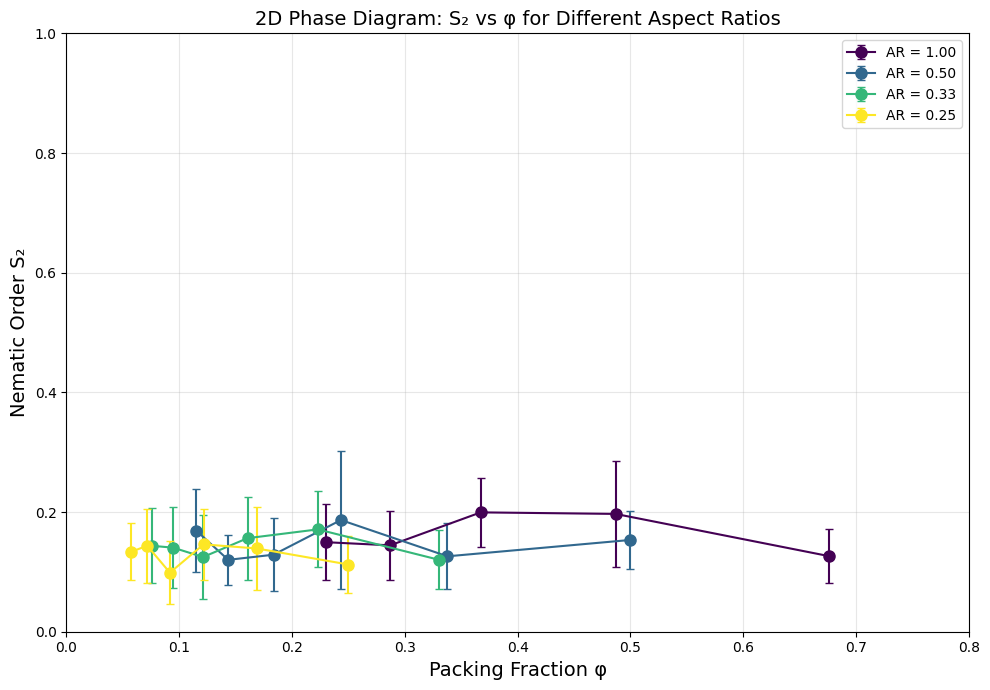

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Polygon
import random

class HardRectangleSim:
    """Hard rectangle Monte Carlo simulation with periodic boundary visualization."""
    
    def __init__(self, N, length, box_size, width=None, aspect_ratio=None):
        self.N = N
        self.length = length
        
        if width is not None:
            self.width = width
        elif aspect_ratio is not None:
            self.width = length * aspect_ratio
        else:
            self.width = length
        
        if self.width > self.length:
            self.length, self.width = self.width, self.length
        
        self.aspect_ratio = self.width / self.length
        self.L = box_size
        self.diagonal = np.sqrt(self.length**2 + self.width**2)
        self.pos = self._init_grid()
        self.angles = np.random.uniform(0, 2*np.pi, N)
        
    def _init_grid(self):
        grid_size = int(np.ceil(np.sqrt(self.N)))
        spacing = self.L / grid_size
        pos = []
        for i in range(self.N):
            x = (i % grid_size) * spacing + spacing / 2
            y = (i // grid_size) * spacing + spacing / 2
            pos.append([x, y])
        return np.array(pos, dtype=float)

    def get_corners(self, center, angle):
        s, c = np.sin(angle), np.cos(angle)
        R = np.array([[c, -s], [s, c]])
        half_l, half_w = self.length / 2, self.width / 2
        corners = np.array([[-half_l, -half_w], [half_l, -half_w],
                           [half_l, half_w], [-half_l, half_w]])
        return center + corners @ R.T

    def get_corners_periodic(self, center, angle):
        """Get corners with periodic boundary handling."""
        corners = self.get_corners(center, angle)
        all_images = []
        
        for dx in [-self.L, 0, self.L]:
            for dy in [-self.L, 0, self.L]:
                shifted_corners = corners + np.array([dx, dy])
                
                if (np.any(shifted_corners[:, 0] > 0) and 
                    np.any(shifted_corners[:, 0] < self.L) and
                    np.any(shifted_corners[:, 1] > 0) and 
                    np.any(shifted_corners[:, 1] < self.L)):
                    all_images.append(shifted_corners)
        
        return all_images

    def check_overlap(self, idx, new_pos, new_angle):
        corners1 = self.get_corners(new_pos, new_angle)
        max_dist = self.diagonal * 1.1
        
        for i in range(self.N):
            if i == idx:
                continue
            dp = self.pos[i] - new_pos
            dp -= self.L * np.round(dp / self.L)
            if np.linalg.norm(dp) > max_dist:
                continue
            corners2 = self.get_corners(new_pos + dp, self.angles[i])
            if self._sat_overlap(corners1, corners2):
                return True
        return False

    def _sat_overlap(self, c1, c2):
        for poly in [c1, c2]:
            for j in range(4):
                edge = poly[(j + 1) % 4] - poly[j]
                normal = np.array([-edge[1], edge[0]])
                p1, p2 = c1 @ normal, c2 @ normal
                if np.max(p1) < np.min(p2) or np.max(p2) < np.min(p1):
                    return False
        return True

    def step(self, dr_max=0.1, da_max=0.1):
        accepted = 0
        for _ in range(self.N):
            idx = random.randint(0, self.N - 1)
            old_p, old_a = self.pos[idx].copy(), self.angles[idx]
            new_p = old_p + (np.random.rand(2) - 0.5) * dr_max
            new_a = old_a + (np.random.rand() - 0.5) * da_max
            new_p %= self.L
            if not self.check_overlap(idx, new_p, new_a):
                self.pos[idx], self.angles[idx] = new_p, new_a
                accepted += 1
        return accepted / self.N

    def packing_fraction(self):
        return self.N * self.length * self.width / self.L**2

    def nematic_order_parameter(self):
        Q = np.zeros((2, 2))
        for angle in self.angles:
            n = np.array([np.cos(angle), np.sin(angle)])
            Q += np.outer(n, n) - 0.5 * np.eye(2)
        Q /= self.N
        return 2 * np.max(np.abs(np.linalg.eigvalsh(Q)))

    def tetratic_order_parameter(self):
        return np.abs(np.mean(np.exp(1j * 4 * self.angles)))

    def local_nematic_order(self, r_cut=None):
        if r_cut is None:
            r_cut = 2.0 * self.length
        local_S2 = np.zeros(self.N)
        for i in range(self.N):
            neighbors = [i]
            for j in range(self.N):
                if i == j:
                    continue
                dp = self.pos[j] - self.pos[i]
                dp -= self.L * np.round(dp / self.L)
                if np.linalg.norm(dp) < r_cut:
                    neighbors.append(j)
            Q = np.zeros((2, 2))
            for j in neighbors:
                n = np.array([np.cos(self.angles[j]), np.sin(self.angles[j])])
                Q += np.outer(n, n) - 0.5 * np.eye(2)
            Q /= len(neighbors)
            local_S2[i] = 2 * np.max(np.abs(np.linalg.eigvalsh(Q)))
        return local_S2

    def radial_distribution_function(self, n_bins=100, r_max=None):
        if r_max is None:
            r_max = self.L / 2
        dr = r_max / n_bins
        bins = np.linspace(0, r_max, n_bins + 1)
        hist = np.zeros(n_bins)
        for i in range(self.N):
            for j in range(i + 1, self.N):
                dp = self.pos[j] - self.pos[i]
                dp -= self.L * np.round(dp / self.L)
                r = np.linalg.norm(dp)
                if r < r_max:
                    bin_idx = int(r / dr)
                    if bin_idx < n_bins:
                        hist[bin_idx] += 2
        r_centers = (bins[:-1] + bins[1:]) / 2
        rho = self.N / self.L**2
        g_r = np.zeros(n_bins)
        for i in range(n_bins):
            shell_area = np.pi * ((bins[i+1])**2 - (bins[i])**2)
            ideal_count = rho * shell_area * self.N
            if ideal_count > 0:
                g_r[i] = hist[i] / ideal_count
        return r_centers, g_r

    def spatial_correlation_function(self, n_bins=50, r_max=None):
        if r_max is None:
            r_max = self.L / 2
        dr = r_max / n_bins
        bins = np.linspace(0, r_max, n_bins + 1)
        correlation, counts = np.zeros(n_bins), np.zeros(n_bins)
        for i in range(self.N):
            for j in range(i + 1, self.N):
                dp = self.pos[j] - self.pos[i]
                dp -= self.L * np.round(dp / self.L)
                r = np.linalg.norm(dp)
                if r < r_max:
                    bin_idx = int(r / dr)
                    if bin_idx < n_bins:
                        delta_angle = self.angles[j] - self.angles[i]
                        correlation[bin_idx] += np.cos(2 * delta_angle)
                        counts[bin_idx] += 1
        with np.errstate(divide='ignore', invalid='ignore'):
            g2_r = np.where(counts > 0, correlation / counts, 0)
        return (bins[:-1] + bins[1:]) / 2, g2_r

    def angle_distribution(self, n_bins=36):
        normalized_angles = self.angles % np.pi
        hist, bin_edges = np.histogram(normalized_angles, bins=n_bins, range=(0, np.pi))
        return (bin_edges[:-1] + bin_edges[1:]) / 2, hist / self.N

    def director(self):
        Q = np.zeros((2, 2))
        for angle in self.angles:
            n = np.array([np.cos(angle), np.sin(angle)])
            Q += np.outer(n, n) - 0.5 * np.eye(2)
        Q /= self.N
        eigenvalues, eigenvectors = np.linalg.eigh(Q)
        max_idx = np.argmax(np.abs(eigenvalues))
        director = eigenvectors[:, max_idx]
        return np.arctan2(director[1], director[0]), 2 * np.abs(eigenvalues[max_idx])

    def save_gif(self, filename='hard_rectangle.gif', n_frames=100, 
                 sweeps_per_frame=5, fps=20, dr_max=0.5, da_max=0.5,
                 equilibrate=200, colorby='orientation', show_order=True,
                 show_periodic=True):
        """Save simulation as GIF with periodic boundary visualization."""
        phi = self.packing_fraction()
        print(f"\n{'='*50}")
        print(f"Saving: {filename}")
        print(f"N={self.N}, {self.length:.1f}×{self.width:.1f}, φ={phi:.3f}")
        print(f"Periodic display: {show_periodic}")
        print(f"{'='*50}")
        
        if equilibrate > 0:
            print(f"Equilibrating ({equilibrate} sweeps)...")
            for i in range(equilibrate):
                acc = self.step(dr_max=dr_max, da_max=da_max)
                if (i + 1) % 100 == 0:
                    print(f"  Sweep {i+1}, acceptance = {acc:.2f}")
        
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.set_xlim(0, self.L)
        ax.set_ylim(0, self.L)
        ax.set_aspect('equal')
        ax.set_facecolor('#f8f8f8')
        
        if colorby == 'index':
            base_colors = plt.cm.viridis(np.linspace(0, 1, self.N))
        else:
            base_colors = plt.cm.hsv(self.angles % np.pi / np.pi)
        
        particle_patches = {}
        
        def create_patches():
            for idx in list(particle_patches.keys()):
                for patch in particle_patches[idx]:
                    patch.remove()
            particle_patches.clear()
            
            for i in range(self.N):
                if colorby == 'orientation':
                    color = plt.cm.hsv((self.angles[i] % np.pi) / np.pi)
                else:
                    color = base_colors[i]
                
                particle_patches[i] = []
                
                if show_periodic:
                    all_corners = self.get_corners_periodic(self.pos[i], self.angles[i])
                    for j, corners in enumerate(all_corners):
                        alpha = 0.8 if j == 0 or len(all_corners) == 1 else 0.5
                        poly = Polygon(corners, closed=True,
                                      facecolor=color, edgecolor='black',
                                      alpha=alpha, linewidth=1)
                        ax.add_patch(poly)
                        particle_patches[i].append(poly)
                else:
                    corners = self.get_corners(self.pos[i], self.angles[i])
                    poly = Polygon(corners, closed=True,
                                  facecolor=color, edgecolor='black',
                                  alpha=0.8, linewidth=1)
                    ax.add_patch(poly)
                    particle_patches[i].append(poly)
        
        create_patches()
        
        title = ax.set_title(f'Hard Rectangles | {self.length:.1f}×{self.width:.1f} | φ={phi:.3f} | Sweep: 0',
                            fontsize=11, fontweight='bold')
        
        if show_order:
            S2 = self.nematic_order_parameter()
            order_text = ax.text(0.02, 0.98, f'S₂ = {S2:.3f}',
                                transform=ax.transAxes, fontsize=11,
                                verticalalignment='top',
                                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        def animate(frame):
            for _ in range(sweeps_per_frame):
                self.step(dr_max=dr_max, da_max=da_max)
            
            create_patches()
            
            sweep_num = frame * sweeps_per_frame
            title.set_text(f'Hard Rectangles | {self.length:.1f}×{self.width:.1f} | φ={phi:.3f} | Sweep: {sweep_num}')
            
            if show_order:
                S2 = self.nematic_order_parameter()
                order_text.set_text(f'S₂ = {S2:.3f}')
            
            all_patches = []
            for patches in particle_patches.values():
                all_patches.extend(patches)
            
            if show_order:
                return all_patches + [title, order_text]
            return all_patches + [title]
        
        print(f"\nCreating animation ({n_frames} frames)...")
        anim = animation.FuncAnimation(fig, animate, frames=n_frames,
                                       interval=1000/fps, blit=False)
        
        print(f"Saving...")
        anim.save(filename, writer='pillow', fps=fps)
        
        print(f"\nDone! Saved as {filename}")
        plt.close()


# ============================================
# VISUALIZATION FUNCTION
# ============================================

def visualize_configuration(sim, ax=None, title=None, show_periodic=True):
    """Visualize current configuration with periodic boundaries."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    phi = sim.packing_fraction()
    colors = plt.cm.hsv(sim.angles % np.pi / np.pi)
    
    for i in range(sim.N):
        if show_periodic:
            all_corners = sim.get_corners_periodic(sim.pos[i], sim.angles[i])
            for j, corners in enumerate(all_corners):
                alpha = 0.8 if j == 0 or len(all_corners) == 1 else 0.4
                poly = Polygon(corners, closed=True,
                              facecolor=colors[i], edgecolor='black', alpha=alpha)
                ax.add_patch(poly)
        else:
            corners = sim.get_corners(sim.pos[i], sim.angles[i])
            poly = Polygon(corners, closed=True,
                          facecolor=colors[i], edgecolor='black', alpha=0.8)
            ax.add_patch(poly)
    
    ax.set_xlim(0, sim.L)
    ax.set_ylim(0, sim.L)
    ax.set_aspect('equal')
    
    if title is None:
        title = f'Rectangles {sim.length:.1f}×{sim.width:.1f} (N={sim.N}, φ={phi:.3f})'
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    
    return ax


# ============================================
# ANALYSIS FUNCTIONS
# ============================================

def run_and_analyze(N=36, length=3.0, width=1.0, box_size=20.0,
                    equilibration_sweeps=500, production_sweeps=500,
                    show_periodic=True):
    """Run simulation and perform structural analysis."""
    sim = HardRectangleSim(N, length, box_size, width=width)
    phi = sim.packing_fraction()
    
    print(f"{'='*50}")
    print(f"Hard Rectangle Simulation")
    print(f"{'='*50}")
    print(f"N={N}, {length}×{width}, L={box_size}, φ={phi:.3f}")
    
    print("\nEquilibrating...")
    for i in range(equilibration_sweeps):
        acc = sim.step(dr_max=0.5, da_max=0.5)
        if i % 100 == 0:
            print(f"  Sweep {i}, acceptance = {acc:.2f}")
    
    print("\nProduction run...")
    g_r_samples, S2_samples, psi4_samples, g2_r_samples = [], [], [], []
    
    for i in range(production_sweeps):
        sim.step(dr_max=0.5, da_max=0.5)
        if i % 10 == 0:
            r, g_r = sim.radial_distribution_function()
            g_r_samples.append(g_r)
            S2_samples.append(sim.nematic_order_parameter())
            psi4_samples.append(sim.tetratic_order_parameter())
            r_corr, g2_r = sim.spatial_correlation_function()
            g2_r_samples.append(g2_r)
        if i % 100 == 0:
            print(f"  Sweep {i}")
    
    g_r_avg = np.mean(g_r_samples, axis=0)
    g2_r_avg = np.mean(g2_r_samples, axis=0)
    S2_avg, S2_std = np.mean(S2_samples), np.std(S2_samples)
    psi4_avg = np.mean(psi4_samples)
    
    angle_bins, angle_hist = sim.angle_distribution()
    local_S2 = sim.local_nematic_order()
    director_angle, _ = sim.director()
    
    print(f"\n{'='*50}")
    print(f"RESULTS: S₂={S2_avg:.3f}±{S2_std:.3f}, Ψ₄={psi4_avg:.3f}")
    print(f"{'='*50}")
    
    fig = plt.figure(figsize=(16, 12))
    
    ax1 = fig.add_subplot(2, 3, 1)
    visualize_configuration(sim, ax1, show_periodic=show_periodic)
    ax1.set_title(f'Configuration (φ={phi:.3f})')
    
    ax2 = fig.add_subplot(2, 3, 2)
    ax2.plot(r, g_r_avg, 'b-', lw=2)
    ax2.axhline(1, color='gray', ls='--')
    ax2.set_xlabel('r'); ax2.set_ylabel('g(r)'); ax2.set_title('RDF')
    
    ax3 = fig.add_subplot(2, 3, 3)
    ax3.plot(r_corr, g2_r_avg, 'g-', lw=2)
    ax3.axhline(0, color='gray', ls='--')
    ax3.set_xlabel('r'); ax3.set_ylabel('g₂(r)'); ax3.set_title('Nematic Correlation')
    
    ax4 = fig.add_subplot(2, 3, 4)
    ax4.bar(np.degrees(angle_bins), angle_hist, width=180/len(angle_bins)*0.8, 
            color='purple', alpha=0.7)
    ax4.set_xlabel('Angle (deg)'); ax4.set_ylabel('P')
    ax4.set_title(f'Angle Distribution (S₂={S2_avg:.3f})')
    
    ax5 = fig.add_subplot(2, 3, 5)
    ax5.plot(S2_samples, 'b-', alpha=0.7, label=f'S₂={S2_avg:.3f}')
    ax5.plot(psi4_samples, 'r-', alpha=0.7, label=f'Ψ₄={psi4_avg:.3f}')
    ax5.set_xlabel('Sample'); ax5.set_ylabel('Order'); ax5.legend(); ax5.set_ylim(0, 1)
    
    ax6 = fig.add_subplot(2, 3, 6)
    sc = ax6.scatter(sim.pos[:, 0], sim.pos[:, 1], c=local_S2, cmap='coolwarm', 
                     s=200, vmin=0, vmax=1, edgecolors='black')
    ax6.set_xlim(0, sim.L); ax6.set_ylim(0, sim.L); ax6.set_aspect('equal')
    plt.colorbar(sc, ax=ax6, label='Local S₂')
    ax6.set_title('Local Nematic Order')
    
    plt.tight_layout()
    plt.savefig('rectangle_analysis.png', dpi=150)
    plt.show()
    
    return sim, {'phi': phi, 'S2': S2_avg, 'S2_std': S2_std, 'psi4': psi4_avg,
                 'r': r, 'g_r': g_r_avg, 'r_corr': r_corr, 'g2_r': g2_r_avg}


def aspect_ratio_scan(aspect_ratios=[1.0, 0.7, 0.5, 0.33, 0.25], N=25, 
                      length=2.0, box_size=18.0, sweeps=300):
    """Scan different aspect ratios."""
    results = []
    for ar in aspect_ratios:
        width = length * ar
        sim = HardRectangleSim(N, length, box_size, width=width)
        print(f"\nAR={ar:.2f}, φ={sim.packing_fraction():.3f}")
        
        for _ in range(300):
            sim.step(dr_max=0.5, da_max=0.5)
        
        S2_vals, psi4_vals = [], []
        for _ in range(sweeps):
            sim.step(dr_max=0.5, da_max=0.5)
            S2_vals.append(sim.nematic_order_parameter())
            psi4_vals.append(sim.tetratic_order_parameter())
        
        results.append({'ar': ar, 'phi': sim.packing_fraction(),
                       'S2': np.mean(S2_vals), 'S2_std': np.std(S2_vals),
                       'psi4': np.mean(psi4_vals), 'psi4_std': np.std(psi4_vals)})
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ars = [r['ar'] for r in results]
    ax.errorbar(ars, [r['S2'] for r in results], yerr=[r['S2_std'] for r in results],
                fmt='o-', capsize=5, label='S₂ (nematic)', markersize=8, color='blue')
    ax.errorbar(ars, [r['psi4'] for r in results], yerr=[r['psi4_std'] for r in results],
                fmt='s-', capsize=5, label='Ψ₄ (tetratic)', markersize=8, color='red')
    ax.set_xlabel('Aspect Ratio (width/length)', fontsize=12)
    ax.set_ylabel('Order Parameter', fontsize=12)
    ax.set_title('Order Parameters vs Aspect Ratio', fontsize=14)
    ax.legend(fontsize=11)
    ax.set_ylim(0, 1)
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('aspect_ratio_scan.png', dpi=150)
    plt.show()
    return results


def density_scan(box_sizes=[25, 22, 20, 18, 16], N=25, length=3.0, width=1.0, sweeps=300):
    """Scan different densities for fixed aspect ratio."""
    results = []
    for L in box_sizes:
        sim = HardRectangleSim(N, length, L, width=width)
        print(f"\nφ={sim.packing_fraction():.3f}")
        
        for _ in range(300):
            sim.step(dr_max=0.5, da_max=0.5)
        
        S2_vals, psi4_vals = [], []
        for _ in range(sweeps):
            sim.step(dr_max=0.5, da_max=0.5)
            S2_vals.append(sim.nematic_order_parameter())
            psi4_vals.append(sim.tetratic_order_parameter())
        
        results.append({
            'phi': sim.packing_fraction(), 
            'S2': np.mean(S2_vals), 
            'S2_std': np.std(S2_vals),
            'psi4': np.mean(psi4_vals),
            'psi4_std': np.std(psi4_vals)
        })
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.errorbar([r['phi'] for r in results], [r['S2'] for r in results],
                yerr=[r['S2_std'] for r in results], fmt='o-', capsize=5, 
                markersize=8, color='blue', label='S₂ (nematic)')
    ax.errorbar([r['phi'] for r in results], [r['psi4'] for r in results],
                yerr=[r['psi4_std'] for r in results], fmt='s-', capsize=5, 
                markersize=8, color='red', label='Ψ₄ (tetratic)')
    ax.set_xlabel('Packing Fraction φ', fontsize=12)
    ax.set_ylabel('Order Parameter', fontsize=12)
    ax.set_title(f'Phase Diagram (AR={width/length:.2f})', fontsize=14)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('density_scan.png', dpi=150)
    plt.show()
    return results


# ============================================
# PHASE DIAGRAM SCAN FUNCTION
# ============================================

def phase_diagram_scan(box_sizes=[25, 22, 20, 18, 16, 14], N=25, 
                       length=3.0, width=1.0, equilibration_sweeps=300,
                       production_sweeps=300, save_snapshots=False,
                       show_periodic=True):
    """
    Scan different packing fractions to map phase behavior.
    
    Parameters:
    -----------
    box_sizes : list
        List of box sizes to scan (smaller = higher density)
    N : int
        Number of particles
    length : float
        Rectangle length
    width : float
        Rectangle width
    equilibration_sweeps : int
        Number of equilibration sweeps per state point
    production_sweeps : int
        Number of production sweeps for measurements
    save_snapshots : bool
        If True, save configuration snapshots at each density
    show_periodic : bool
        Show periodic boundaries in snapshots
    
    Returns:
    --------
    results : list of dict
        Results for each state point
    """
    
    results = []
    aspect_ratio = width / length
    
    print("=" * 60)
    print("PHASE DIAGRAM SCAN")
    print("=" * 60)
    print(f"N = {N}, Rectangle: {length} × {width} (AR = {aspect_ratio:.2f})")
    print(f"Box sizes: {box_sizes}")
    print("=" * 60)
    
    for L in box_sizes:
        sim = HardRectangleSim(N, length, L, width=width)
        phi = sim.packing_fraction()
        
        print(f"\n{'─'*40}")
        print(f"Running φ = {phi:.3f} (L = {L})...")
        print(f"{'─'*40}")
        
        # Equilibration
        print(f"  Equilibrating ({equilibration_sweeps} sweeps)...")
        for i in range(equilibration_sweeps):
            acc = sim.step(dr_max=0.5, da_max=0.5)
            if (i + 1) % 100 == 0:
                print(f"    Sweep {i+1}, acceptance = {acc:.2f}")
        
        # Production - collect measurements
        print(f"  Production ({production_sweeps} sweeps)...")
        S2_vals = []
        psi4_vals = []
        
        for i in range(production_sweeps):
            sim.step(dr_max=0.5, da_max=0.5)
            
            if i % 5 == 0:  # Sample every 5 sweeps
                S2_vals.append(sim.nematic_order_parameter())
                psi4_vals.append(sim.tetratic_order_parameter())
        
        # Calculate statistics
        S2_mean = np.mean(S2_vals)
        S2_std = np.std(S2_vals)
        psi4_mean = np.mean(psi4_vals)
        psi4_std = np.std(psi4_vals)
        
        print(f"  Results: S₂ = {S2_mean:.3f} ± {S2_std:.3f}, Ψ₄ = {psi4_mean:.3f} ± {psi4_std:.3f}")
        
        results.append({
            'phi': phi,
            'L': L,
            'S2': S2_mean,
            'S2_std': S2_std,
            'psi4': psi4_mean,
            'psi4_std': psi4_std,
            'S2_series': S2_vals,
            'psi4_series': psi4_vals
        })
        
        # Save snapshot if requested
        if save_snapshots:
            fig, ax = plt.subplots(figsize=(6, 6))
            visualize_configuration(sim, ax, show_periodic=show_periodic)
            ax.set_title(f'φ = {phi:.3f}, S₂ = {S2_mean:.3f}')
            plt.tight_layout()
            plt.savefig(f'snapshot_phi_{phi:.3f}.png', dpi=100)
            plt.close()
    
    # ============================================
    # PLOTTING
    # ============================================
    
    print("\n" + "=" * 60)
    print("GENERATING PLOTS")
    print("=" * 60)
    
    phis = [r['phi'] for r in results]
    S2s = [r['S2'] for r in results]
    S2_errs = [r['S2_std'] for r in results]
    psi4s = [r['psi4'] for r in results]
    psi4_errs = [r['psi4_std'] for r in results]
    
    # Plot 1: Phase diagram
    fig, ax = plt.subplots(figsize=(10, 7))
    
    ax.errorbar(phis, S2s, yerr=S2_errs, fmt='o-', capsize=5, 
                label='S₂ (nematic)', color='blue', markersize=10, linewidth=2)
    ax.errorbar(phis, psi4s, yerr=psi4_errs, fmt='s-', capsize=5, 
                label='Ψ₄ (tetratic)', color='red', markersize=10, linewidth=2)
    
    ax.set_xlabel('Packing Fraction φ', fontsize=14)
    ax.set_ylabel('Order Parameter', fontsize=14)
    ax.set_title(f'Hard Rectangle Phase Diagram\n{length}×{width} (AR = {aspect_ratio:.2f}), N = {N}', 
                fontsize=14)
    ax.legend(fontsize=12, loc='upper left')
    ax.set_xlim(0, max(phis) * 1.1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    
    # Add phase regions (approximate)
    if max(phis) > 0.3:
        ax.axvspan(0, 0.3, alpha=0.1, color='green', label='Isotropic')
        ax.axvspan(0.3, 0.5, alpha=0.1, color='yellow', label='Transition')
        if max(phis) > 0.5:
            ax.axvspan(0.5, max(phis)*1.1, alpha=0.1, color='red', label='Ordered')
    
    plt.tight_layout()
    plt.savefig('phase_diagram.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Plot 2: Order parameter time series for each density
    n_densities = len(results)
    fig, axes = plt.subplots(2, (n_densities + 1) // 2, figsize=(14, 8))
    axes = axes.flatten()
    
    for i, r in enumerate(results):
        ax = axes[i]
        ax.plot(r['S2_series'], 'b-', alpha=0.7, label='S₂')
        ax.plot(r['psi4_series'], 'r-', alpha=0.7, label='Ψ₄')
        ax.axhline(r['S2'], color='blue', linestyle='--', linewidth=2)
        ax.axhline(r['psi4'], color='red', linestyle='--', linewidth=2)
        ax.set_xlabel('Sample')
        ax.set_ylabel('Order')
        ax.set_title(f'φ = {r["phi"]:.3f}')
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
    
    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('Order Parameter Time Series at Different Densities', fontsize=14)
    plt.tight_layout()
    plt.savefig('phase_diagram_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(f"{'φ':>8} {'S₂':>10} {'±':>6} {'Ψ₄':>10} {'±':>6}")
    print("-" * 45)
    for r in results:
        print(f"{r['phi']:>8.3f} {r['S2']:>10.3f} {r['S2_std']:>6.3f} {r['psi4']:>10.3f} {r['psi4_std']:>6.3f}")
    print("=" * 60)
    
    return results


def phase_diagram_2d(N_values=[16, 25, 36], aspect_ratios=[1.0, 0.5, 0.33, 0.25],
                     box_size_range=(12, 25), n_densities=5, sweeps=200):
    """
    Create 2D phase diagram varying both aspect ratio and density.
    
    Parameters:
    -----------
    N_values : list
        Different particle numbers to test (for finite-size effects)
    aspect_ratios : list
        Different aspect ratios to scan
    box_size_range : tuple
        (min_box, max_box) range for density scan
    n_densities : int
        Number of density points per aspect ratio
    sweeps : int
        Production sweeps per state point
    
    Returns:
    --------
    results_2d : dict
        2D results grid
    """
    
    print("=" * 60)
    print("2D PHASE DIAGRAM SCAN")
    print("=" * 60)
    
    results_2d = {}
    length = 2.0  # Fixed length
    N = N_values[-1]  # Use largest N
    
    for ar in aspect_ratios:
        width = length * ar
        print(f"\n{'='*40}")
        print(f"Aspect Ratio: {ar:.2f} ({length}×{width:.2f})")
        print(f"{'='*40}")
        
        results_2d[ar] = []
        
        # Generate box sizes for this aspect ratio
        box_sizes = np.linspace(box_size_range[1], box_size_range[0], n_densities)
        
        for L in box_sizes:
            sim = HardRectangleSim(N, length, L, width=width)
            phi = sim.packing_fraction()
            
            # Skip if packing fraction too high (likely jammed)
            if phi > 0.8:
                continue
            
            print(f"  φ = {phi:.3f}...", end=" ")
            
            # Equilibrate
            for _ in range(200):
                sim.step(dr_max=0.5, da_max=0.5)
            
            # Measure
            S2_vals = []
            for _ in range(sweeps):
                sim.step(dr_max=0.5, da_max=0.5)
                if _ % 5 == 0:
                    S2_vals.append(sim.nematic_order_parameter())
            
            S2_mean = np.mean(S2_vals)
            print(f"S₂ = {S2_mean:.3f}")
            
            results_2d[ar].append({
                'phi': phi,
                'S2': S2_mean,
                'S2_std': np.std(S2_vals)
            })
    
    # Plot 2D phase diagram
    fig, ax = plt.subplots(figsize=(10, 7))
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(aspect_ratios)))
    
    for i, ar in enumerate(aspect_ratios):
        if len(results_2d[ar]) > 0:
            phis = [r['phi'] for r in results_2d[ar]]
            S2s = [r['S2'] for r in results_2d[ar]]
            S2_errs = [r['S2_std'] for r in results_2d[ar]]
            
            ax.errorbar(phis, S2s, yerr=S2_errs, fmt='o-', capsize=3,
                       color=colors[i], label=f'AR = {ar:.2f}', markersize=8)
    
    ax.set_xlabel('Packing Fraction φ', fontsize=14)
    ax.set_ylabel('Nematic Order S₂', fontsize=14)
    ax.set_title('2D Phase Diagram: S₂ vs φ for Different Aspect Ratios', fontsize=14)
    ax.legend(fontsize=10)
    ax.set_xlim(0, 0.8)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('phase_diagram_2d.png', dpi=150)
    plt.show()
    
    return results_2d


def save_multiple_gifs(show_periodic=True):
    """Save GIFs for different aspect ratios."""
    configs = [
        ('rect_ar100_periodic.gif', 1.0, 1.0),
        ('rect_ar050_periodic.gif', 2.0, 1.0),
        ('rect_ar033_periodic.gif', 3.0, 1.0),
        ('rect_ar025_periodic.gif', 4.0, 1.0),
    ]
    for filename, length, width in configs:
        sim = HardRectangleSim(N=20, length=length, box_size=15.0, width=width)
        sim.save_gif(filename=filename, n_frames=100, equilibrate=200, 
                    show_periodic=show_periodic)


# ============================================
# MAIN EXECUTION
# ============================================

if __name__ == "__main__":
    
    print("=" * 60)
    print("HARD RECTANGLE SIMULATION WITH PERIODIC BOUNDARIES")
    print("=" * 60)
    
    # ----------------------------------------
    # Option 1: Single simulation with GIF
    # ----------------------------------------
    sim = HardRectangleSim(N=20, length=3.0, width=1.0, box_size=15.0)
    sim.save_gif(
        filename='hard_rectangle_periodic.gif', 
        n_frames=100, 
        equilibrate=200,
        show_periodic=True
    )
    
    # ----------------------------------------
    # Option 2: Full analysis
    # ----------------------------------------
    # Uncomment to run
    
    # sim, results = run_and_analyze(
    #     N=25,
    #     length=3.0,
    #     width=1.0,
    #     box_size=20.0,
    #     equilibration_sweeps=500,
    #     production_sweeps=500,
    #     show_periodic=True
    # )
    
    # ----------------------------------------
    # Option 3: Aspect ratio scan
    # ----------------------------------------
    # Uncomment to run
    
    # ar_results = aspect_ratio_scan(
    #     aspect_ratios=[1.0, 0.7, 0.5, 0.33, 0.25],
    #     N=25,
    #     length=2.0,
    #     box_size=18.0
    # )
    
    # ----------------------------------------
    # Option 4: Density scan
    # ----------------------------------------
    # Uncomment to run
    
    # density_results = density_scan(
    #     box_sizes=[25, 22, 20, 18, 16],
    #     N=25,
    #     length=3.0,
    #     width=1.0
    # )
    
    # ----------------------------------------
    # Option 5: Phase diagram scan
    # ----------------------------------------
    # Uncomment to run
    
    # phase_results = phase_diagram_scan(
    #     box_sizes=[25, 22, 20, 18, 16, 14, 12],
    #     N=25,
    #     length=3.0,
    #     width=1.0,
    #     equilibration_sweeps=300,
    #     production_sweeps=300,
    #     save_snapshots=True,
    #     show_periodic=True
    # )
    
    # ----------------------------------------
    # Option 6: 2D Phase diagram (AR vs density)
    # ----------------------------------------
    # Uncomment to run
    
    results_2d = phase_diagram_2d(
        aspect_ratios=[1.0, 0.5, 0.33, 0.25],
        box_size_range=(12, 25),
        n_densities=6,
        sweeps=200
    )
    
    # ----------------------------------------
    # Option 7: Multiple GIFs for different aspect ratios
    # ----------------------------------------
    # Uncomment to run
    
    # save_multiple_gifs(show_periodic=True)